# ¿Serás reemplazado por IA?
## Resumen

Este proyecto analiza qué características determinan el destino de un empleado tras la adopción de inteligencia artificial en su empresa, clasificándolo en una de tres categorías: puesto sin cambios, modificado o reemplazado. El objetivo es identificar qué variables (personales, del puesto o de la empresa) explican realmente el riesgo de reemplazo de un empleado, y construir así un modelo predictivo que sea interpretable y capaz de cuantificar ese riesgo.

## Contexto de la base de datos

La base de datos cuenta con 2.000 observaciones, 17 variables con información personal del empleado (edad, género, educación, satisfacción), características del puesto (rol, industria, horas semanales, salario pre y post IA) y contexto empresarial (nivel de adopción de IA, riesgo de automatización). La variable objetivo `Job_Status` distribuye las observaciones en tres clases: Unchanged (54,6%), Modified (40,0%) y Replaced (5,3%), con un fuerte desbalance hacia las clases mayoritarias. Dando por entendido que aún no estamos en una etapa de reemplazo masivo.

**Naturaleza del dataset:** Durante el EDA identifiqué que las distribuciones de las variables (numéricas) aparentan ser uniformes y presentan valores acotados lo que supone ausencia de outliers. Esto implica que las conclusiones cuantitativas del proyecto son válidas dentro de los datos disponibles, pero no deben extrapolarse sin más a poblaciones reales sin validación extra. Esta limitación queda desarrollada en la sección final del notebook.

## Principales hallazgos

1. **Las variables personales del empleado no predicen el reemplazo.** Edad, experiencia, salario previo, satisfacción, productividad, género y nivel educativo tienen capacidad predictiva prácticamente nula entre los tres estados del puesto. Las diferencias entre grupos son más pequeñas que la dispersión dentro de cada grupo.

2. **Dos variables estructurales concentran todo el poder predictivo.** El riesgo de automatización del puesto (`Automation_Risk`) y el nivel de adopción de IA de la empresa (`AI_Adoption_Level`) explican aproximadamente el 95% de la capacidad predictiva del modelo. Todas las demás variables aportan efectos residuales.

3. **El efecto acumulado multiplica el riesgo por 26 veces.** Un empleado en el escenario de mayor exposición (puesto de alto riesgo en empresa de alta adopción) tiene aproximadamente 26 veces más probabilidades de ser reemplazado que uno en el escenario opuesto. Es decir, el reemplazo por IA es una cuestión de estructura del puesto y contexto empresarial, no del perfil del empleado.

## Estructura del notebook

El notebook sigue el flujo estándar de un proyecto ML supervisado:

- **A.** Importación de librerías y configuración del entorno.
- **B.** Carga del dataset y foto inicial (dtypes, nulos, duplicados, cardinalidad).
- **C.** Análisis exploratorio completo: descriptivos, distribuciones, análisis bivariado con el target, relaciones multivariantes y detección de outliers.
- **D.** Ingeniería de variables derivadas (Feature Engineering).
- **E.** Proceso predictivo: preprocesado, entrenamiento de cinco modelos con GridSearchCV, análisis de estabilidad por folds y selección final del modelo.
- **F.** Interpretación de los coeficientes del modelo ganador en términos de odds ratios.
- **G.** Representación visual de los insights más importantes del proyecto.

Cada sección viene acompañada de markdowns interpretativos que conectan los resultados numéricos con conclusiones dirigidas a un público general.

## Decisiones a tener en cuenta durante el estudio

- **Criterio de selección del modelo:** principio de parsimonia. Ante rendimientos equivalentes entre modelos de distinta complejidad, se eligió LogisticRegression por su interpretabilidad directa a través de coeficientes, evitando modelos complejos de interpretar.
- **Manejo del desbalance.** Se utilizó `class_weight='balanced'` en todos los modelos que lo permiten y se eligió F1 macro como métrica de referencia, no la accuracy. De este modo, tratamos de hacer frente al desbalanceo del estado más determinante en el estudio `Replaced`.
- **Prevención de data leakage.** Variables como `Salary_After_AI` y `salary_delta`, que son consecuencia del target, se excluyeron del input pese a su poder predictivo.
- **Feature engineering mínimo.** Se crearon solo tres variables derivadas (una de ellas exclusivamente para análisis complementario), priorizando la simplicidad.

### A. IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN DEL ENTORNO

In [2]:
# Tratamiento de datos
import pandas as pd
import numpy as np

# Visualizacion
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración
import warnings
import os
from pathlib import Path

# Sklearn
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder,
    LabelEncoder
)

from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, 
    GradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["figure.facecolor"] = "white"

palette_status = {"Replaced": "#d62728", "Modified": "#ff7f0e", "Unchanged": "#2ca02c"}

### B. CARGA DE LA BASE DE DATOS Y FOTO ESTÁTICA

Trataremos lo siguiente:
- Carga de los datos
- Foto inicial de la estructura y estado de la base de datos

In [3]:
path = 'ai_job_impact.csv'
df = pd.read_csv(path)

print(df.head)

<bound method NDFrame.head of      Employee_ID  Age  Gender Education_Level       Industry  \
0          E0001   50  Female        Bachelor      Marketing   
1          E0002   45    Male     High School  Manufacturing   
2          E0003   51  Female          Master             IT   
3          E0004   48    Male             PhD      Education   
4          E0005   24    Male        Bachelor     Healthcare   
...          ...  ...     ...             ...            ...   
1995       E1996   55   Other             PhD     Healthcare   
1996       E1997   31    Male             PhD        Finance   
1997       E1998   43  Female        Bachelor         Retail   
1998       E1999   43  Female        Bachelor      Marketing   
1999       E2000   23   Other          Master      Marketing   

                Job_Role  Years_Experience AI_Adoption_Level Automation_Risk  \
0        Content Creator                26              High            High   
1      Quality Inspector                1

In [4]:
print(f'Tamaño del dataset: Filas:{df.shape[0]} | Columnas:{df.shape[1]}')
print('-'*40)
print(f'Columnas: \n{list(df.columns)}')
print('-'*40)
print(f'Tipos de datos: \n{df.dtypes}')
print('-'*40)
print(f'Estructura del dataset: \n{df.head()}')
print('-'*40)
print(f'Analisis de nulos inicial: \n{df.isnull().sum()}')
print('-'*40)
print(f'Filas duplicadas: \n{df.duplicated().sum()}')
print('-'*40)
categoricas = df.select_dtypes(['object', 'string']).columns.tolist()
print('Valores únicos por categórica:')
for cat in categoricas:
    vals = df[cat].unique()
    if len(vals) > 8:
        print(f'{cat}:{len(vals)} únicos, son muchos valores hay que agrupar')
    else:
        print(f'{cat}:{len(vals)} únicos✅')
print('-'*40)
orden_ordinal = {
    'AI_Adoption_Level': ['Low', 'Medium', 'High'],
    'Automation_Risk': ['Low', 'Medium', 'High'],
    'Education_Level': ['High School', 'Bachelor', 'Master', 'PhD'],
}
for col, order in orden_ordinal.items():
    df[col] = pd.Categorical(df[col], categories=order, ordered=True)
    print(f'{col} : {df[col].dtype}')
    print('Conversion exitosa✅')

Tamaño del dataset: Filas:2000 | Columnas:17
----------------------------------------
Columnas: 
['Employee_ID', 'Age', 'Gender', 'Education_Level', 'Industry', 'Job_Role', 'Years_Experience', 'AI_Adoption_Level', 'Automation_Risk', 'Upskilling_Required', 'Salary_Before_AI', 'Salary_After_AI', 'Job_Status', 'Work_Hours_Per_Week', 'Remote_Work', 'Job_Satisfaction', 'Productivity_Change_%']
----------------------------------------
Tipos de datos: 
Employee_ID                  str
Age                        int64
Gender                       str
Education_Level              str
Industry                     str
Job_Role                     str
Years_Experience           int64
AI_Adoption_Level            str
Automation_Risk              str
Upskilling_Required          str
Salary_Before_AI           int64
Salary_After_AI            int64
Job_Status                   str
Work_Hours_Per_Week        int64
Remote_Work                  str
Job_Satisfaction           int64
Productivity_Change_% 

La foto inicial nos indica los siguientes puntos importantes:
- Predominancia de variables categóricas(9) respecto a numéricas(7)
- No contienen nulos las variables
- Convertimos variables categóricas a ordinales, de forma que podemos modelar dando importancia al orden y que no lo ignoren los modelos
- No hay errores typo

### C. EDA - ANÁLISIS EXPLORATORIO: DEL DESCRIPTIVO - BIVARIADO
Trataremos los siguientes aspectos:
- Estadísticos descriptivos
- Distribuciones
- Relaciones variables
- Análisis multivariante

In [5]:
#Distribuciones categoricas y objetivo

print(f'Descriptivos: \n{df.describe().round(2)}')
print('-'*40)
print(f'Distribución variable objetivo: \n{df['Job_Status'].value_counts(normalize = True)}')
print('-'*40)
for cat in [c for c in categoricas if c not in ['Employee_ID', 'Job_Status']]:
    print(f'Distribución variable: \n{df[cat].value_counts(normalize = True)}')
    print('-'*40)
print('-'*40)
print('Descriptivos por Job_Status:')
print(df.groupby('Job_Status').agg({
    'Age': ['mean', 'std'],
    'Years_Experience': ['mean', 'std'],
    'Salary_Before_AI': ['mean', 'std'],
    'Salary_After_AI': ['mean', 'std'],
    'Productivity_Change_%': ['mean', 'std'],
    'Job_Satisfaction': ['mean', 'std'],
}).round(2))
print('-'*40)
# Comprobación de consistencia lógica
inconsistencias = df[df['Age'] < df['Years_Experience'] + 15]
print(f'Filas con Age < Years_Experience + 15: {len(inconsistencias)}')
if len(inconsistencias) > 0:
    print(inconsistencias[['Age', 'Years_Experience']].head())


Descriptivos: 
           Age  Years_Experience  Salary_Before_AI  Salary_After_AI  \
count  2000.00           2000.00           2000.00          2000.00   
mean     40.56             16.66          73942.07         78428.64   
std      10.79             10.75          26055.82         29351.60   
min      22.00              0.00          30036.00         24447.00   
25%      32.00              8.00          51665.50         54086.75   
50%      40.00             16.00          74620.00         76820.50   
75%      50.00             26.00          95418.25        100730.25   
max      59.00             37.00         119976.00        161745.00   

       Work_Hours_Per_Week  Job_Satisfaction  Productivity_Change_%  
count              2000.00           2000.00                2000.00  
mean                 44.85              6.02                   9.79  
std                   5.71              2.01                  17.19  
min                  35.00              3.00                 -19.

In [6]:
# Cuantificación del desbalance
print('Implicaciones del desbalance:')
target_dist = df['Job_Status'].value_counts()
print(f'  Ratio mayoritaria/minoritaria: {target_dist.max()/target_dist.min():.1f}x')
print(f'  Casos Replaced en 80/20 split: ~{int(target_dist["Replaced"] * 0.2)} en test')
print(f'  Accuracy de un dummy (siempre Unchanged): {target_dist.max()/target_dist.sum():.1%}')

Implicaciones del desbalance:
  Ratio mayoritaria/minoritaria: 10.3x
  Casos Replaced en 80/20 split: ~21 en test
  Accuracy de un dummy (siempre Unchanged): 54.6%


### Hallazgos del análisis descriptivo

**Variable objetivo fuertemente desbalanceada.** La distribución de `Job_Status` es 54,65% Unchanged / 40,05% Modified / 5,30% Replaced. El ratio entre la clase mayoritaria y la minoritaria es de 10,3x, lo que sitúa el problema en un desbalance severo. Un modelo trivial que prediga siempre 'Unchanged' alcanzaría ya 54,6% de accuracy sin aprender nada, por lo que este valor 54,6% es el límite inferior; un modelo mínimamente informativo, por lo tanto cualquier modelo para ser considerado útil deberá superarlo. Además, un split de train/test (80/20) dejará solo unos 21 casos de 'Replaced' en el conjunto de test: cualquier métrica calculada sobre esa clase tendrá alta varianza .

**Decisión de modelado derivada:** usaremos métricas para combatir el desbalance (F1 macro, balanced accuracy, recall de la clase minoritaria) como criterio principal de selección, y 'class_weight='balanced''', adicionalmente, ante el fuerte desbalance, evaluaremos un ajuste del threshold de decisión. Usare accuracy aunque no será la métrica en la que base mi criterio de decisión.

**Las variables individuales del empleado no discriminan entre estados del remplazo.** Al dividir las variables numéricas por `Job_Status`, las medias entre los tres grupos son prácticamente idénticas: apenas 1,5 años de diferencia en edad y experiencia, 4.000 euros en salario previo, una décima en satisfacción y un punto porcentual en productividad. Las desviaciones típicas dentro de cada grupo (+-10 años en edad, +-26.000 euros en salario, +-2 puntos en satisfacción) son  mayores que las diferencias entre grupos. En términos estadísticos, la varianza intragrupal excede con diferencia la varianza intergrupo para las variables numéricas.

**Consistencia lógica del dataset.** El check lógico realizado 'Age ≥ Years_Experience + 15' se cumple en las 2000 filas sin excepciones. La base de datos respeta la restricción de que nadie comienza a trabajar antes de los 15 años.

**Homogeneidad de las categóricas nominales.** `Gender`, `Education_Level`, `Industry`, `AI_Adoption_Level` y `Automation_Risk` tienen distribuciones aproximadamente uniformes entre sus niveles (entre 13% y 35% cada uno). No hay categorías minoritarias problemáticas que requieran agrupación. `Upskilling_Required` y `Remote_Work` están prácticamente al 50/50.

**`Job_Role` merece atención.** 21 niveles con frecuencias entre 4,0% y 5,6% cada uno. La distribución es uniforme pero la cardinalidad es alta. Sobre 2000 filas tenemos ~80-110 observaciones por rol, lo que está en el límite aceptable para modelado. Al aplicar One-Hot Encoding generaría 20 columnas nuevas (con `drop_first=True`), por lo que evaluaremos en el análisis bivariado si tiene sentido agrupar roles por similitud funcional (p. ej., Digital Marketer + SEO Specialist + Content Creator = 'Marketing/Content') o si conviene mantenerlos separados.

**Descartes.** `Employee_ID` es un identificador único sin valor predictivo y se eliminará antes del modelado. Las variables `Salary_After_AI` y sus derivadas (que generaremos más adelante, como `salary_delta`) deberán excluirse del input cuando el target sea `Job_Status`, para evitar data leakage: ambas son consecuencia directa del estado del puesto tras la adopción de IA.

---

**Resumen de decisiones tras el descriptivo estadístico:**
1. Baseline mínimo a superar: 54,6% de accuracy (dummy clase mayoritaria).
2. Métricas principales de evaluación: F1 macro, balanced accuracy, recall de `Replaced`.
3. Estrategia para el desbalance: `class_weight='balanced'` en los modelos que lo soporten; reconsiderar con SMOTE si el recall de `Replaced` queda bajo.
4. `Employee_ID` se descartará. `Job_Role` se mantiene por ahora; decisión de agrupación sujeta al bivariado.

Dataset limpio: (2000, 17)
Variables numéricas: 
['Age', 'Years_Experience', 'Salary_Before_AI', 'Salary_After_AI', 'Work_Hours_Per_Week', 'Job_Satisfaction', 'Productivity_Change_%']
Variables categóricas: 
['Employee_ID', 'Gender', 'Education_Level', 'Industry', 'Job_Role', 'AI_Adoption_Level', 'Automation_Risk', 'Upskilling_Required', 'Job_Status', 'Remote_Work']


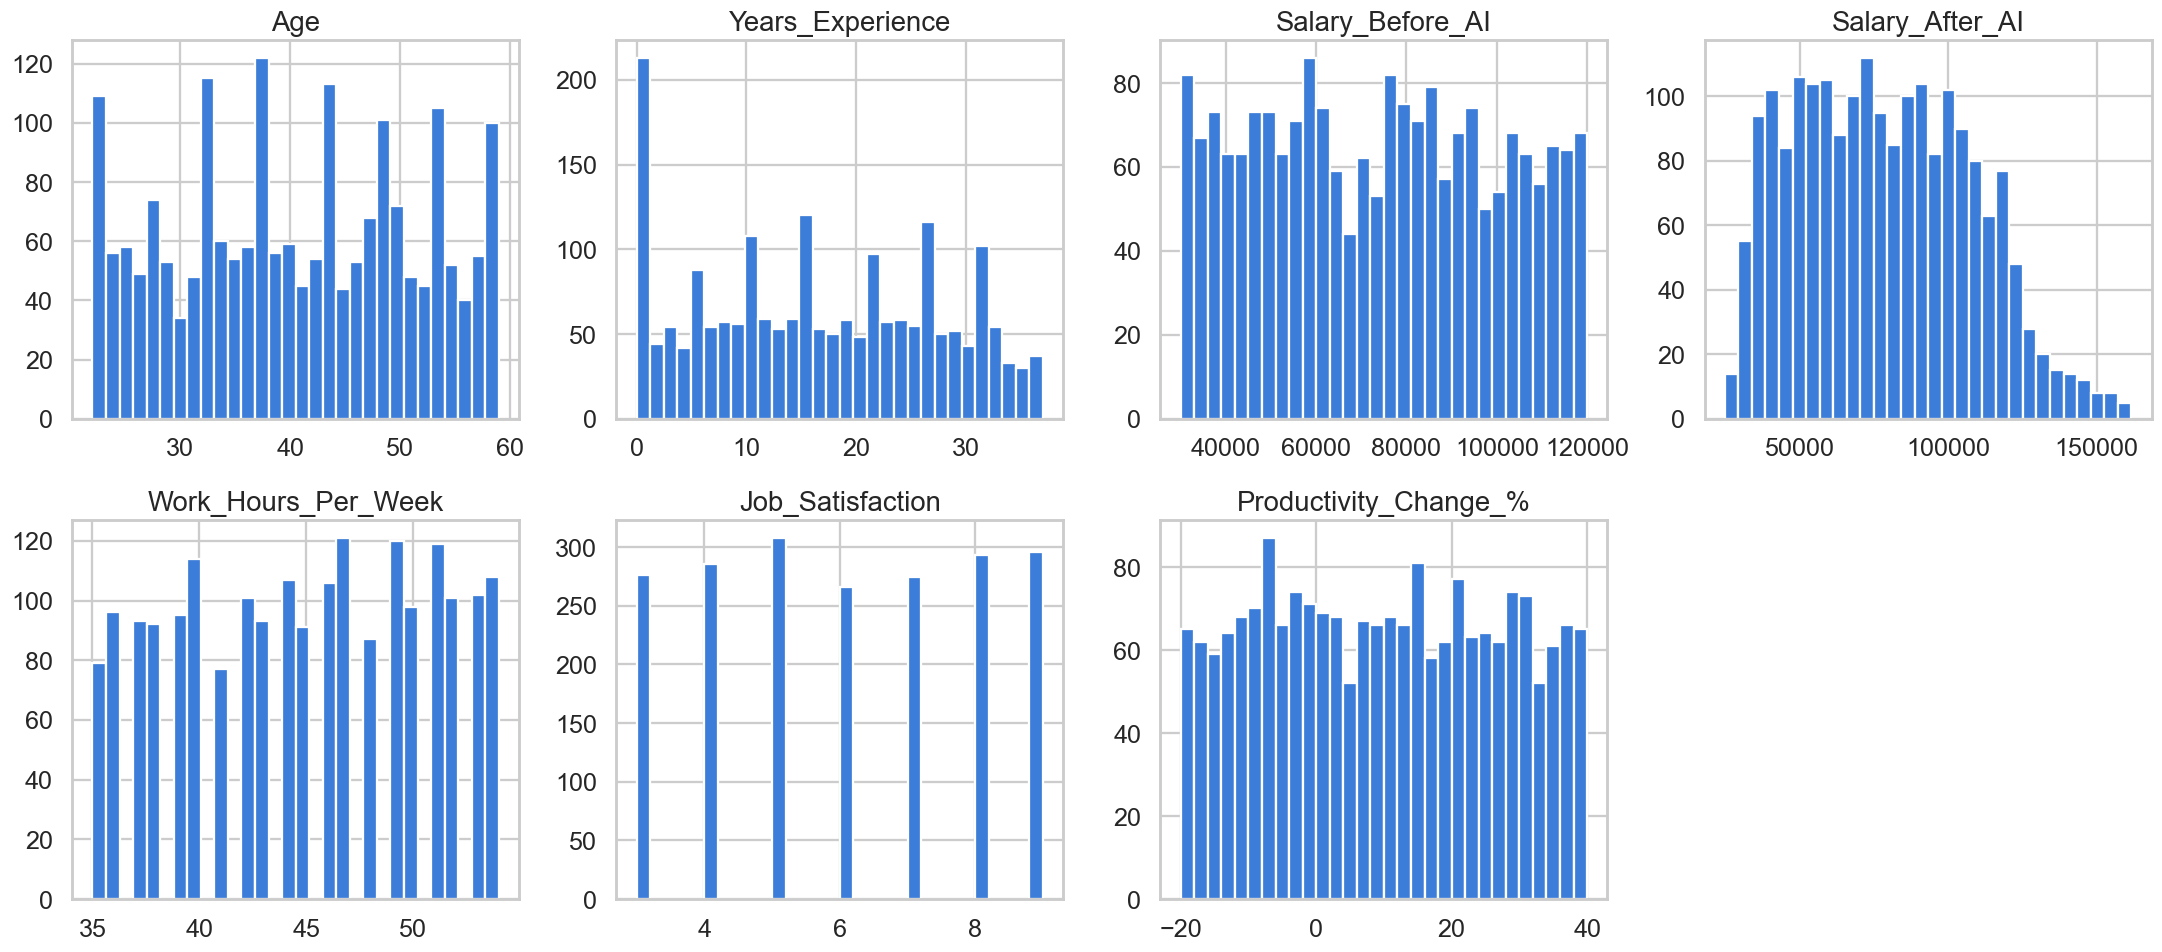

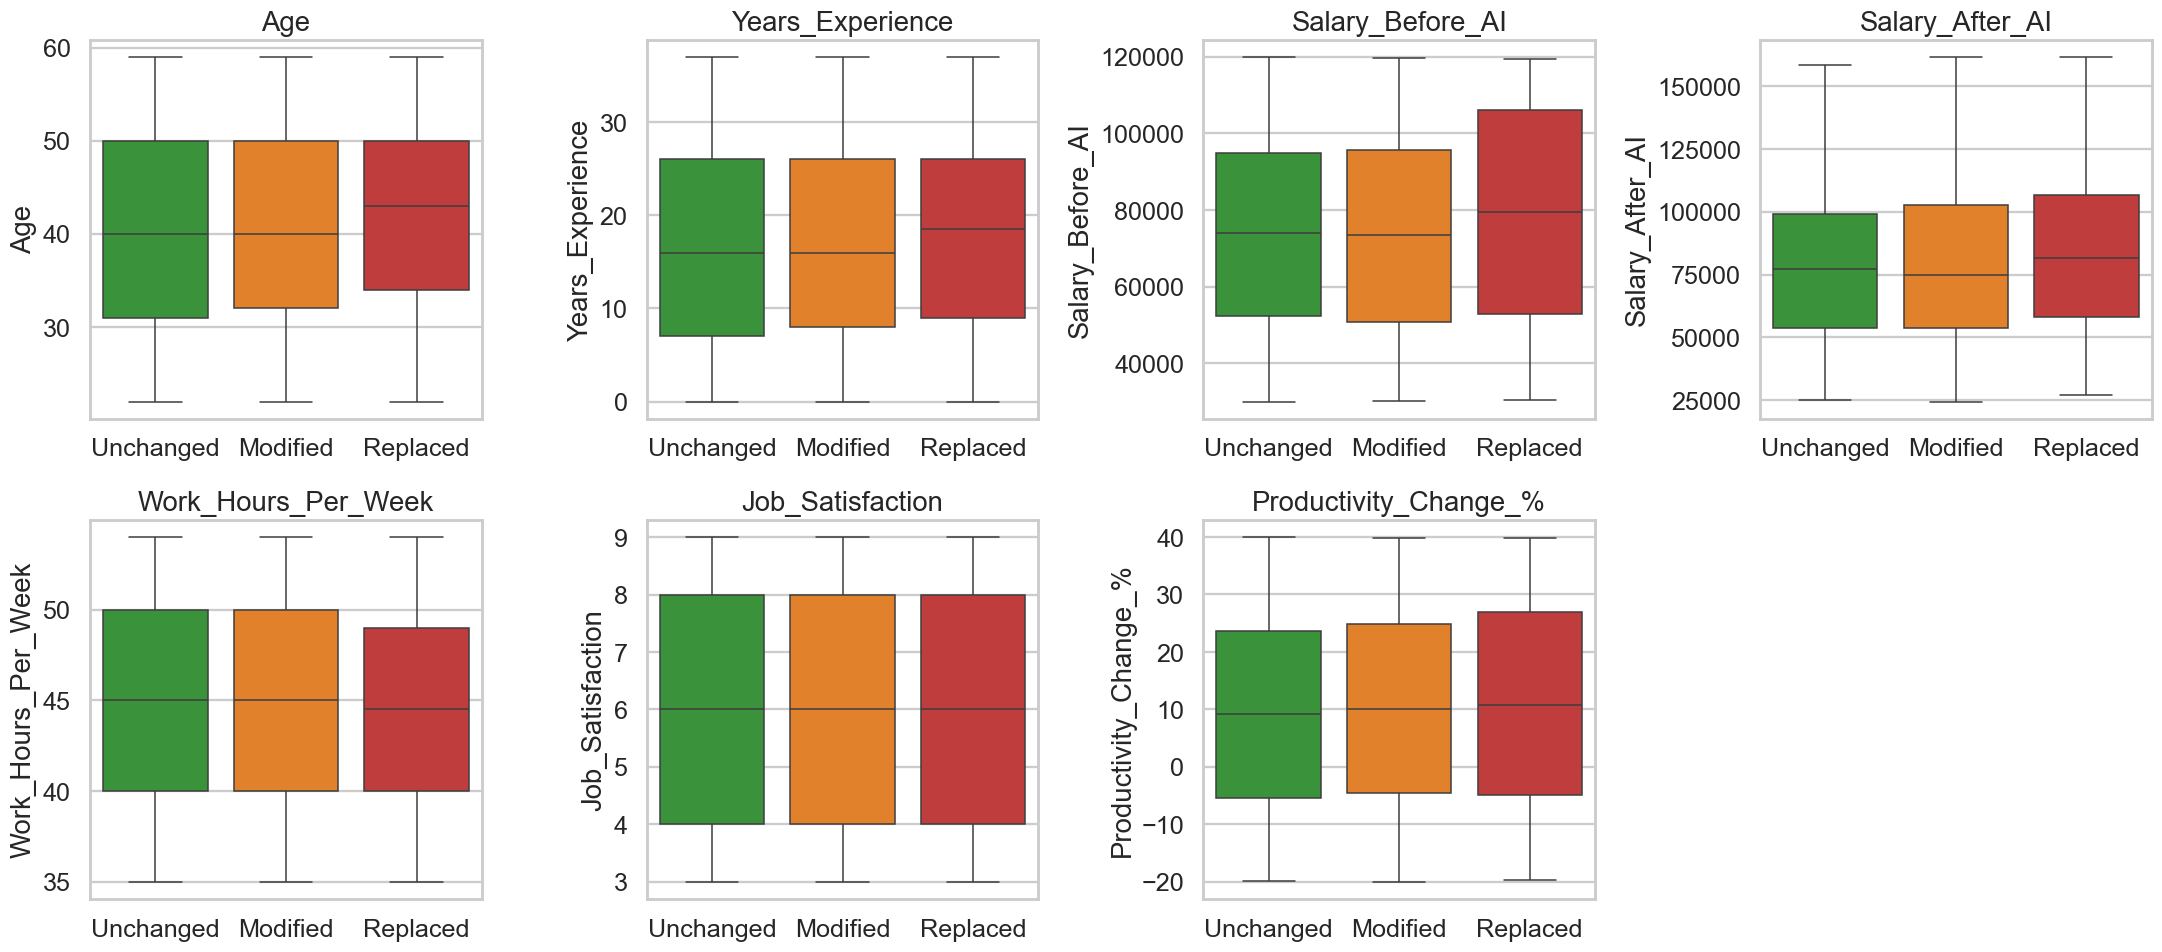

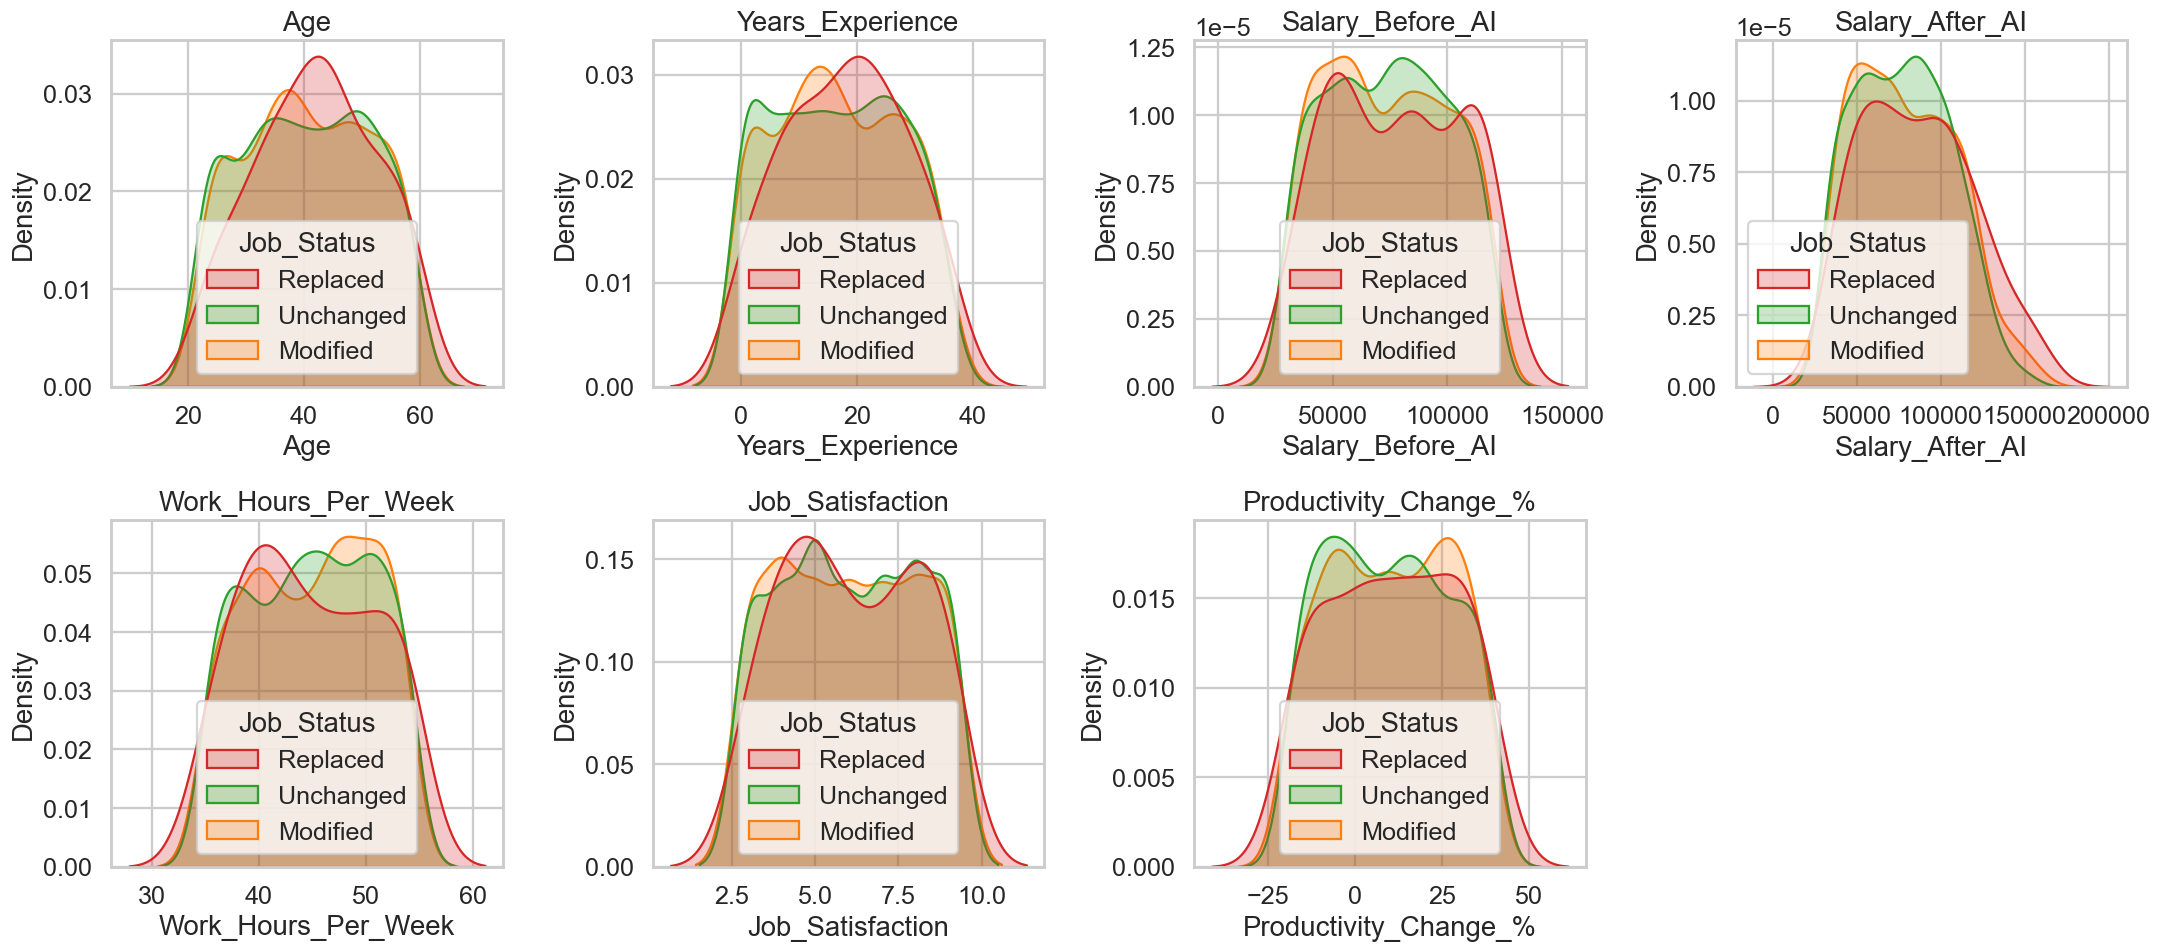

In [7]:
# Distribuciones univariantes (visuales)
# Numéricas: histogramas + boxplots (outliers)
# Categóricas: countplots
#df = df.drop(columns=['Employee_ID'])
print(f'Dataset limpio: {df.shape}')

numericas = df.select_dtypes(['int64', 'float64']).columns.tolist()
categoricas = df.select_dtypes(['object', 'string', 'category']).columns.tolist()
print(f'Variables numéricas: \n{numericas}')
print(f'Variables categóricas: \n{categoricas}')

# Histogramas numéricas
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, col in zip(axes.flat, numericas):
    ax.hist(df[col], bins=30, color='#3b7dd8', edgecolor='white')
    ax.set_title(col)
axes.flat[-1].axis('off')  # oculta el subplot sobrante
plt.tight_layout(); plt.show()

# Boxplots numéricas (por 'Job_Status')
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, col in zip(axes.flat, numericas):
    sns.boxplot(data=df, x='Job_Status', y=col,
                order=['Unchanged', 'Modified', 'Replaced'],
                palette=palette_status, ax=ax)
    ax.set_title(col); ax.set_xlabel('')
axes.flat[-1].axis('off')
plt.tight_layout(); plt.show()

# KDE (por 'Job_Status')
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, col in zip(axes.flat, numericas):
    sns.kdeplot(data=df, x=col, hue='Job_Status', palette=palette_status,
            fill=True, alpha=0.25, common_norm=False, ax=ax)
    ax.set_title(col)
axes.flat[-1].axis('off')
plt.tight_layout(); plt.show()

### Hallazgos del análisis visual de distribuciones

**Naturaleza uniforme de las variables numéricas.** Los histogramas de `Age`, `Years_Experience`, `Salary_Before_AI`, `Work_Hours_Per_Week`, `Job_Satisfaction` y `Productivity_Change_%` muestran distribuciones aproximadamente uniformes a lo largo de sus rangos, con picos puntuales en valores (0, 10, 20, 25) años. Esto es típico de procesos generativos sintéticos basados en distribuciones uniformes.

**`Salary_After_AI` es la única con distribución con estructura.** Presenta forma de campana con sesgo positivo y cola derecha que alcanza los 160.000$ (frente a los 120.000$ máximos de `Salary_Before_AI`). La IA, por tanto lejos de homogeneizar salarios, amplifica la dispersión entre ellos: algunos perfiles ven subidas salariales muy superiores al paradigma pre-IA.

**Los boxplots confirman cuantitativamente que las variables individuales no discriminan entre los tres estados del puesto.** Las medianas de Age, Years_Experience, Work_Hours_Per_Week, Job_Satisfaction, Productivity_Change_% y Salary_After_AI son visualmente indistinguibles entre Unchanged, Modified y Replaced, y el IQR se solapan en prácticamente todas las variables. Esto valida la hipótesis de que el destino del puesto tras la adopción de IA no es predecible a partir de características individuales del empleado.

**Excepción: `Salary_Before_AI`.** Los empleados clasificados como `Replaced` tienen un IQR de salario previo claramente desplazado hacia arriba respecto a los otros dos grupos (mediana cercana a 80.000$ frente a ~75.000$ en Unchanged y Modified, con el percentil 75 alcanzando los 105.000$ frente a los 95.000$ de los demás). Los reemplazados ganaban, en promedio, más antes de la IA algo totalmente lógico y con poder argumentativo.

**Confirmación con KDE normalizadas por grupo.** Al renormalizar las densidades por clase del target (`common_norm=False`), las formas de las distribuciones de `Age`, `Years_Experience`, `Work_Hours_Per_Week`, `Job_Satisfaction` y `Productivity_Change_%` son **visualmente indistinguibles** entre los **tres estados del puesto**: mismas modas, mismas colas, misma dispersión. Esto ratifica de forma categórica que estas cinco variables no discriminan entre Unchanged, Modified y Replaced, al igual que ocurria con las variables numéricas.

**La señal real (eje salarial).** Las KDE revelan dos observaciones destacables:
- **`Salary_Before_AI`**: la distribución de Replaced está desplazada hacia la derecha, con moda en ~80-90k frente a ~55-75k de los otros grupos. Los reemplazados ganaban más antes de la IA.
- **`Salary_After_AI`**: la distribución de Replaced mantiene además una cola derecha más larga, extendiéndose hasta 150-200k, por encima de las colas de Unchanged y Modified.

**Interpretación.** Este patrón sugiere que la categoría `Replaced` puede estar agrupando perfiles heterogéneos: por un lado, empleados con alto salario previo cuyo puesto es económicamente rentable de automatizar; por otro, casos de 'reemplazo' que en realidad corresponden a reasignaciones hacia funciones de mayor valor o que reciben compensaciones de salida elevadas que elevan artificialmente `Salary_After_AI`.

**Precaución.** La KDE de Replaced muestra más irregularidades que las de los otros grupos, consecuencia directa de trabajar con solo 106 obs en esa clase. Por lo tanto, las indicaciones o interpretaciones relacionadas con 'Replaced' serán informativas, no con alto poder estadístico.

**Implicación para el modelado.** 
De las siete variables numéricas, `Salary_Before_AI` es la única con capacidad discriminativa visible. Las demás, en ausencia de interacciones con otras variables, no aportarán peso predictivo relevante. Esto nos hace pensar que las variables estructurales del puesto (`Automation_Risk`, `AI_Adoption_Level`, `Industry`, `Job_Role`) tendrán la señal predictiva a modelizar.

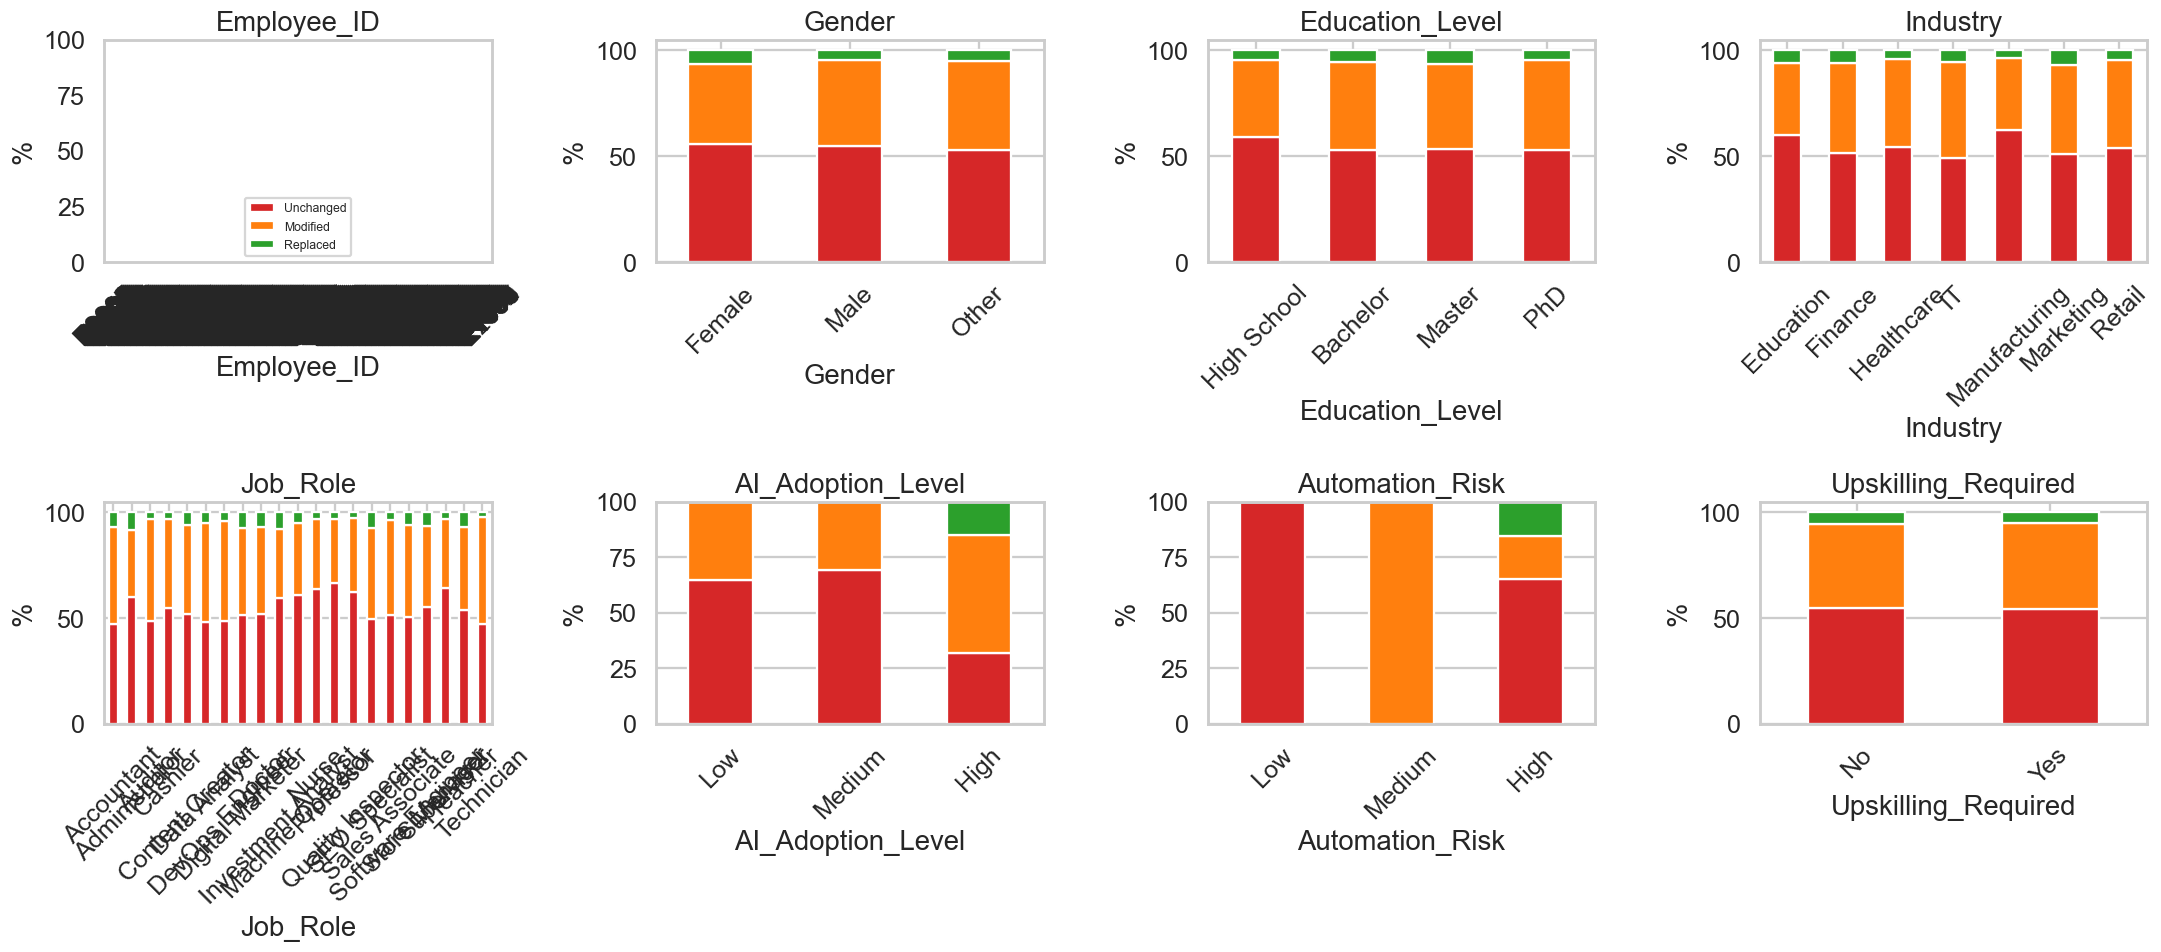

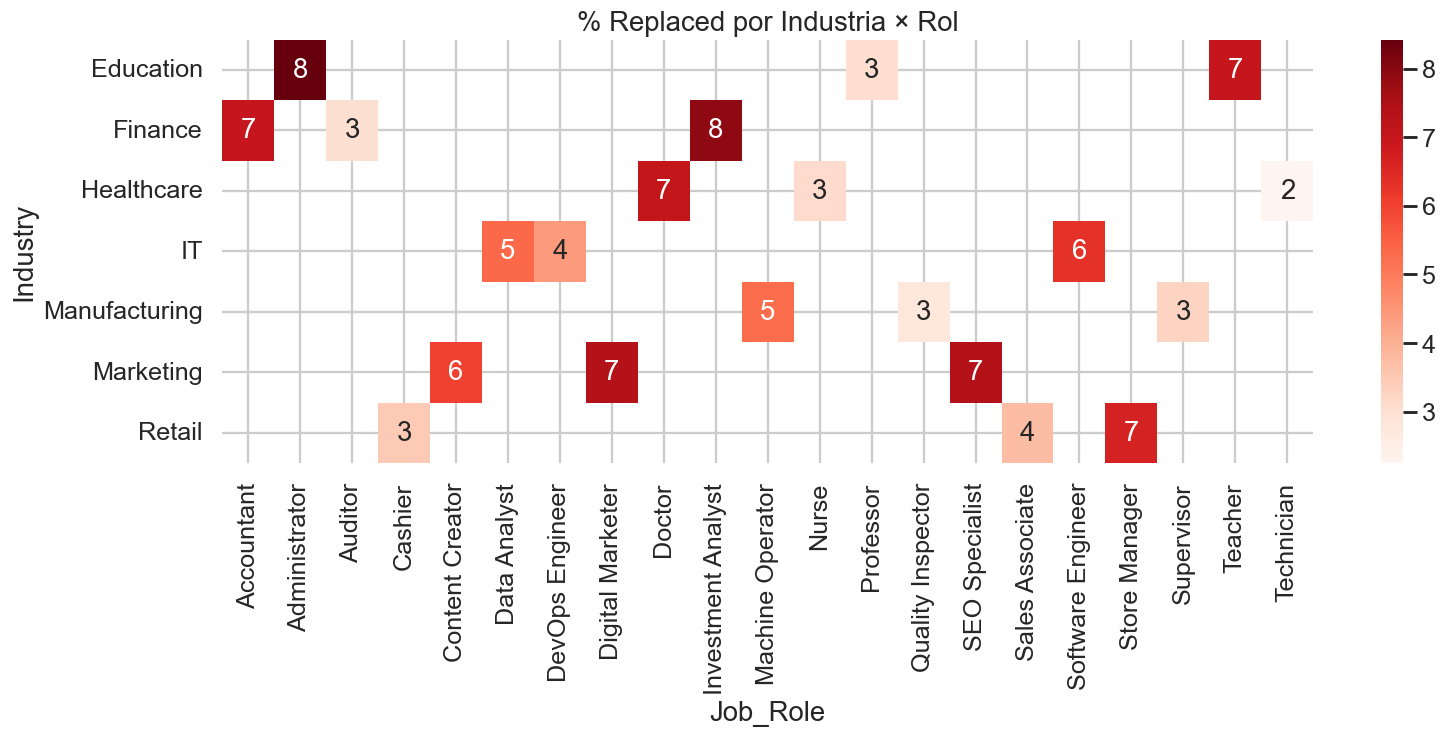

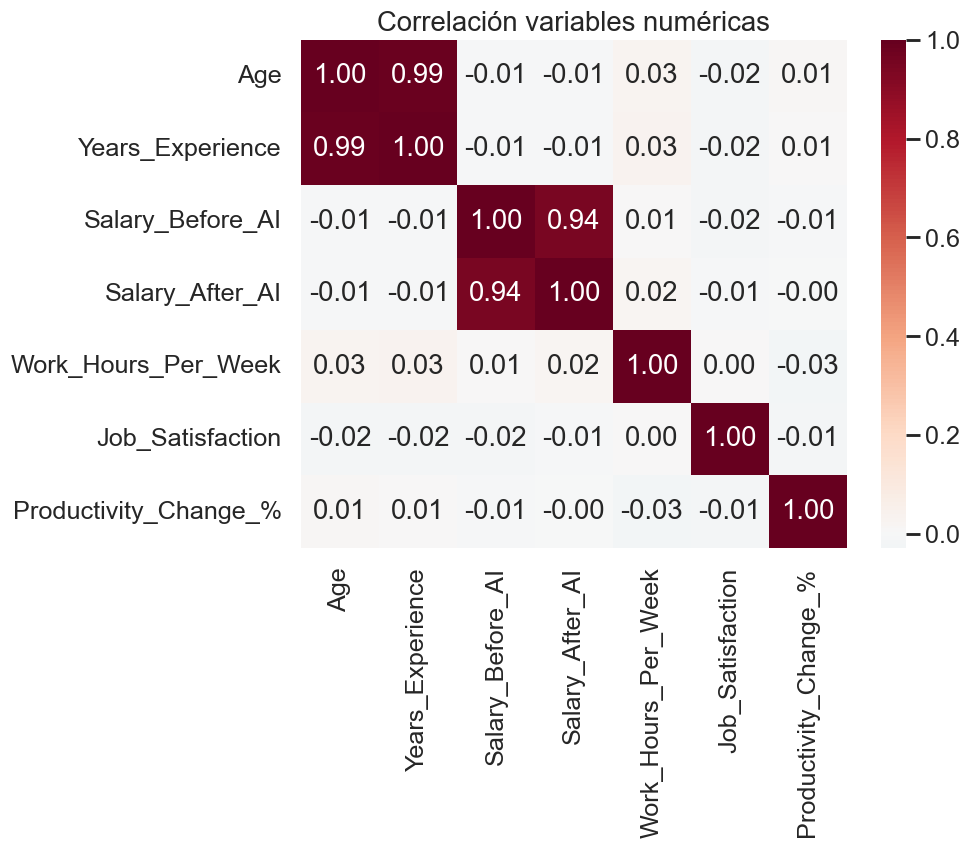

In [8]:
cats_graficar = [c for c in categoricas if c != 'Job_Status']

# Stacked bars
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, col in zip(axes.flat, cats_graficar):
    ct = pd.crosstab(df[col], df['Job_Status'], normalize='index') * 100
    ct[['Unchanged', 'Modified', 'Replaced']].plot(
        kind='bar', stacked=True, color=list(palette_status.values()),
        ax=ax, legend=False)
    ax.set_title(col); ax.set_ylabel('%'); ax.tick_params(axis='x', rotation=45)

axes.flat[0].legend(fontsize=8)
for j in range(len(cats_graficar), len(axes.flat)):
    axes.flat[j].axis('off')
plt.tight_layout(); plt.show

# Heatmap Industry - Job_Role
pivot = pd.crosstab(df['Industry'], df['Job_Role'],
                    values=(df['Job_Status']=='Replaced'), aggfunc='mean') * 100
plt.figure(figsize=(16, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Reds')
plt.title('% Replaced por Industria × Rol'); plt.show()

# Matriz de correlación numéricas
plt.figure(figsize=(8, 6))
sns.heatmap(df[numericas].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlación variables numéricas'); plt.show()

### Hallazgos del análisis bivariado y multivariado

**`Automation_Risk` es la variable con mayor determinismo del target.** Los stacked bars revelan:
- `Low` → prácticamente 100% Unchanged.
- `Medium` → prácticamente 100% Modified.
- `High` → 65% Unchanged, 20% Modified, 15% Replaced.

Es decir, los casos de Replaced solo aparecen dentro de la categoría High. El problema por tanto sería que 'dentro del subconjunto con alto riesgo de automatización, ¿cuáles acaban realmente reemplazados?'.

**`AI_Adoption_Level` es la segunda variable mas determinista.** Los Replaced se concentran casi exclusivamente en empresas con alta adopción de IA. La intersección `Automation_Risk=High × AI_Adoption_Level=High` capturará casi todos los casos de reemplazo. El resto de variables categóricas (Gender, Education_Level, Industry, Job_Role, Upskilling_Required, Remote_Work) muestran distribuciones de Job_Status estadísticamente indistinguibles entre sus niveles, es decir, no aportaran capacidad discriminativa por sí solas, a primera vista.

**Implicación para el modelado:** es esperable que cualquier modelo alcance un alto % de accuracy utilizando únicamente `Automation_Risk` y `AI_Adoption_Level`. Por lo tanto el reto será mas bien fijarnos en el recall de la clase Replaced, que requiere discriminar dentro del subgrupo `Automation_Risk=High`.

**Multicolinealidad entre Age y Years_Experience (r=0.99).** Ambas variables son prácticamente idénticas. Se elimina `Age` del input de los modelos para evitar inestabilidad en los coeficientes lineales y redundancia. `Salary_Before_AI` y `Salary_After_AI` presentan r=0.94, esperable, pero `Salary_After_AI` la íbamos a excluir para evitar el data leakage.

**Redundancia estructural Industry, Job_Role.** En este dataset, cada Job_Role se asocia exclusivamente a una sola Industry, haciendo ambas variables funcionalmente redundantes. Se mantiene `Job_Role` (granularidad superior) y se eliminará `Industry` del input.

---

**Decisiones tras el multivariado:**
1. Variables descartadas adicionalmente: `Age` (multicolinealidad), `Industry` (redundancia con Job_Role).
2. Expectativa realista de métricas: Alto % accuracy por estructura determinista; el foco de evaluación será el recall de `Replaced`.
3. Posible análisis complementario: modelo binario entrenado únicamente sobre `Automation_Risk=High` prediciendo `Replaced vs no-Replaced`, donde reside el problema interesante.

In [9]:
# Análisis de outliers con IQR
print('Análisis de outliers por variable numérica:')
print('-'*40)

for col in numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    pct = len(outliers) / len(df) * 100
    print(f'{col}: {len(outliers)} outliers ({pct:.1f}%)')

Análisis de outliers por variable numérica:
----------------------------------------
Age: 0 outliers (0.0%)
Years_Experience: 0 outliers (0.0%)
Salary_Before_AI: 0 outliers (0.0%)
Salary_After_AI: 0 outliers (0.0%)
Work_Hours_Per_Week: 0 outliers (0.0%)
Job_Satisfaction: 0 outliers (0.0%)
Productivity_Change_%: 0 outliers (0.0%)


### Análisis formal de outliers

Aplicando el criterio IQR (valores fuera de [Q1 - 1.5·IQR, Q3 + 1.5·IQR]) sobre las siete variables numéricas, **ninguna** presenta outliers estadísticos.

Este resultado es coherente con las distribuciones observadas en los histogramas:
- Las variables con distribución uniforme (Age, Years_Experience, Work_Hours_Per_Week, Job_Satisfaction, Productivity_Change_%) tienen por construcción colas acotadas sin valores exagerados.
- Salary_Before_AI y Salary_After_AI, pese a la mayor dispersión visual (valores hasta 161k), tienen IQRs lo suficientemente amplios como para que incluso los extremos caigan dentro del rango esperado.

**Decisiones tras el análisis outliers:**
1. No se requieren tratamientos de outliers previos al modelado.
2. Los valores extremos de Salary_After_AI observados en la cola derecha son estadísticamente consistentes con la distribución general.

### D. FEATURE ENGINEERING

Crearemos las siguientes variables, indicando sus motivos:

- salary_delta: cambio en los salarios comparando ambos paradigmas (pre-post IA)
- ai_risk_combined: variable que capturará el AND lógico entre las dos variables mas explicativas
- experience_group: discretización de Years_Experience

In [10]:
df_modelar = df.copy()

df_modelar['salary_delta'] = df_modelar['Salary_After_AI'] - df_modelar['Salary_Before_AI']

#Los 'Replaced' se concentran casi exclusivamente en Automation_Risk=High y AI_Adoption_Level=High, asique creamos una combinacion
df_modelar['ai_risk_combined'] = (
    df_modelar['Automation_Risk'].astype(str) + '_' + df_modelar['AI_Adoption_Level'].astype(str)
)

# Discretizamos Years_Experience en 4 niveles. Los cortes son a eleccion propia según lo genetal (junior <3, mid 3-8, senior 8-15, director 15+).
df_modelar['experience_group'] = pd.cut(
    df_modelar['Years_Experience'],
    bins=[-0.1, 3, 8, 15, 100],
    labels=['Junior', 'Mid', 'Senior', 'Expert']
)

print('Variables creadas:')
print(df_modelar[['salary_delta', 'ai_risk_combined', 'experience_group']].head())
print(f'\nDistribución:\n{df_modelar['ai_risk_combined'].value_counts(normalize = True)}')
print(f'\nDistribución:\n{df_modelar['experience_group'].value_counts(normalize = True)}')

Variables creadas:
   salary_delta ai_risk_combined experience_group
0        -11365        High_High           Expert
1         -2118          Low_Low           Expert
2          6979    Medium_Medium           Expert
3         -6658    Medium_Medium           Expert
4          7055      Medium_High           Junior

Distribución:
ai_risk_combined
High_Medium      0.1225
Medium_High      0.1200
High_High        0.1195
Low_High         0.1130
Low_Medium       0.1110
Medium_Low       0.1090
Medium_Medium    0.1050
Low_Low          0.1010
High_Low         0.0990
Name: proportion, dtype: float64

Distribución:
experience_group
Expert    0.5275
Senior    0.1965
Junior    0.1555
Mid       0.1205
Name: proportion, dtype: float64


### E. PROCESO PREDICTIVO: PREPROCESADO-MODELADO-SELECCIÓN

Desarrollare todo el proceso predictivo de principio a fin

In [11]:
# Preparación dataset según conclusiones
cols_eliminar = ['Employee_ID', 'Age', 'Industry', 'Salary_After_AI', 'salary_delta', 'Job_Status']

X = df_modelar.drop(cols_eliminar, axis = 1)
y = df_modelar['Job_Status']
print('-'*40)
print(f'Variables predictoras: \n{X}')
print('-'*40)
print(f'Variable objetivo: \n{y}')
print('-'*40)
print(f'Tamaño de X: \nFilas:{X.shape[0]} | Columnas: {X.shape[1]}')
print('-'*40)
print(f'Columnas de X: \n{list(X.columns)}')
print('-'*40)
print(f'\nDistribución de la target: \n{y.value_counts(normalize=True).round(3)}')

# Fijado semilla
seed = 12345

----------------------------------------
Variables predictoras: 
      Gender Education_Level            Job_Role  Years_Experience  \
0     Female        Bachelor     Content Creator                26   
1       Male     High School   Quality Inspector                19   
2     Female          Master     DevOps Engineer                28   
3       Male             PhD             Teacher                24   
4       Male        Bachelor              Doctor                 0   
...      ...             ...                 ...               ...   
1995   Other             PhD          Technician                30   
1996    Male             PhD  Investment Analyst                 9   
1997  Female        Bachelor             Cashier                17   
1998  Female        Bachelor    Digital Marketer                20   
1999   Other          Master      SEO Specialist                 0   

     AI_Adoption_Level Automation_Risk Upskilling_Required  Salary_Before_AI  \
0             

In [12]:
# Split en tr/te
X_train, X_test, y_train, y_test = train_test_split(X,
                                                   y,
                                                   test_size = 0.3,
                                                   random_state = seed,
                                                   stratify = y)
print(f'\nTrain: {X_train.shape} | Test: {X_test.shape}')
print('-'*40)
print(f'Replaced en test: {(y_test=="Replaced").sum()} casos (~5%)')

# Preprocesado
numericas = X.select_dtypes(['int64', 'float64']).columns.tolist()
ordinales = ['AI_Adoption_Level', 'Automation_Risk', 'Education_Level']
categoricas =[c for c in X.columns
                    if c not in numericas and c not in ordinales]
orden_ordinal = {
    'AI_Adoption_Level': ['Low', 'Medium', 'High'],
    'Automation_Risk': ['Low', 'Medium', 'High'],
    'Education_Level': ['High School', 'Bachelor', 'Master', 'PhD'],
}

print('-'*40)
print(f'Numéricas: \n{numericas}')
print('-'*40)
print(f'Ordinales: \n{ordinales}')
print('-'*40)
print(f'Nominales: \n{categoricas}')

preprocesado = ColumnTransformer([
    ('numericas', StandardScaler(), numericas),
    ('categoricas', OneHotEncoder(drop = 'first',
                                  handle_unknown = 'ignore',
                                  sparse_output = False), categoricas),
    ('ordinales', OrdinalEncoder(categories = [orden_ordinal[c] for c in ordinales]), 
     ordinales)
])


Train: (1400, 14) | Test: (600, 14)
----------------------------------------
Replaced en test: 32 casos (~5%)
----------------------------------------
Numéricas: 
['Years_Experience', 'Salary_Before_AI', 'Work_Hours_Per_Week', 'Job_Satisfaction', 'Productivity_Change_%']
----------------------------------------
Ordinales: 
['AI_Adoption_Level', 'Automation_Risk', 'Education_Level']
----------------------------------------
Nominales: 
['Gender', 'Job_Role', 'Upskilling_Required', 'Remote_Work', 'ai_risk_combined', 'experience_group']


Fitting 5 folds for each of 20 candidates, totalling 100 fits


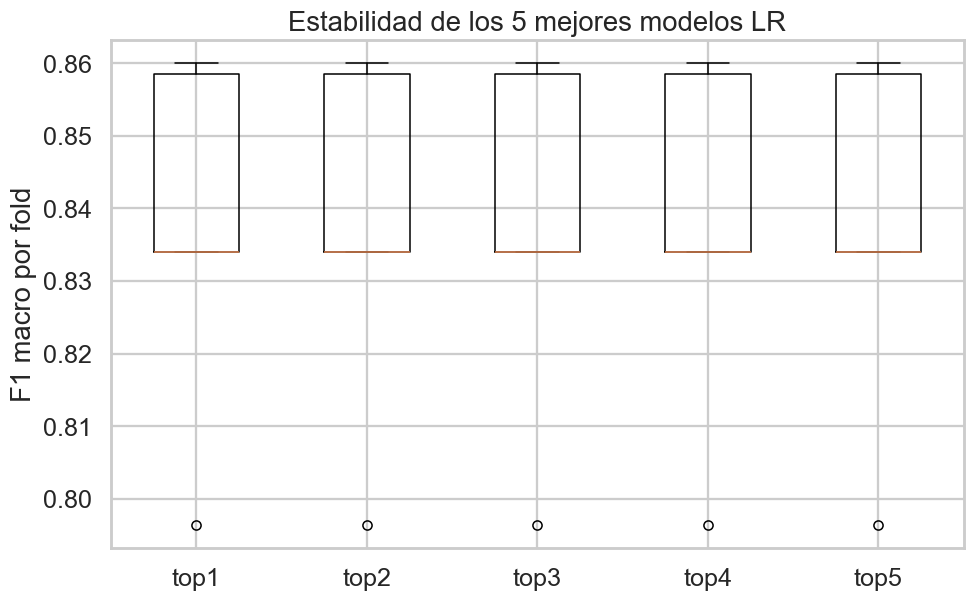

                                              params  mean_test_f1_macro
0  {'modelo__C': 0.1, 'modelo__penalty': 'l2', 's...            0.836567
1  {'modelo__C': 0.1, 'modelo__penalty': 'l2', 's...            0.836567
2  {'modelo__C': 1, 'modelo__penalty': 'l2', 'sel...            0.836567
3  {'modelo__C': 1, 'modelo__penalty': 'l2', 'sel...            0.836567
4  {'modelo__C': 1, 'modelo__penalty': 'l2', 'sel...            0.836567
   param_modelo__C  param_seleccionador__k  mean_test_f1_macro
0              0.1                      13            0.836567
1              0.1                       9            0.836567
2              1.0                      13            0.836567
3              1.0                      11            0.836567
4              1.0                       9            0.836567


In [21]:
# Pipeline Logistic Regression
pipeline_lr = Pipeline([
    ('preprocesado', preprocesado),
    ('seleccionador', SelectKBest(score_func = mutual_info_classif)),
    ('modelo', LogisticRegression(max_iter = 2000,
                                 random_state = seed,
                                 class_weight = 'balanced'))
])

scoring = {
    'accuracy': 'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'f1_macro': 'f1_macro',
}


grid_lr = GridSearchCV(
    estimator = pipeline_lr,
    param_grid = {'seleccionador__k' : [5,7,9,11,13],
                 'modelo__C': [0.01, 0.1, 1, 10],
                 'modelo__penalty': ['l2']},
    scoring = scoring,
    refit = 'f1_macro',
    cv = 5,
    n_jobs = -1, # utilizar todos los nucleos
    verbose = 1, 
)

# Entrenamos
grid_lr.fit(X_train, y_train)

# Generamos y analizamos los resultados
results_lr = pd.DataFrame(grid_lr.cv_results_)
results_lr = results_lr.sort_values('mean_test_f1_macro', ascending=False).reset_index(drop=True)

cols_folds = ['split0_test_f1_macro', 'split1_test_f1_macro',
              'split2_test_f1_macro', 'split3_test_f1_macro',
              'split4_test_f1_macro']

m0 = results_lr[cols_folds].iloc[0]
m1 = results_lr[cols_folds].iloc[1]
m2 = results_lr[cols_folds].iloc[2]
m3 = results_lr[cols_folds].iloc[3]
m4 = results_lr[cols_folds].iloc[4]

plt.figure(figsize=(10, 6))
plt.boxplot([m0.values, m1.values, m2.values, m3.values, m4.values],
            tick_labels=['top1', 'top2', 'top3', 'top4', 'top5'])
plt.ylabel('F1 macro por fold')
plt.title('Estabilidad de los 5 mejores modelos LR')
plt.show()
plt.close()

print(results_lr[['params', 'mean_test_f1_macro']].head(5))
print(results_lr.head(5)[['param_modelo__C', 'param_seleccionador__k', 'mean_test_f1_macro']])

Fitting 5 folds for each of 100 candidates, totalling 500 fits


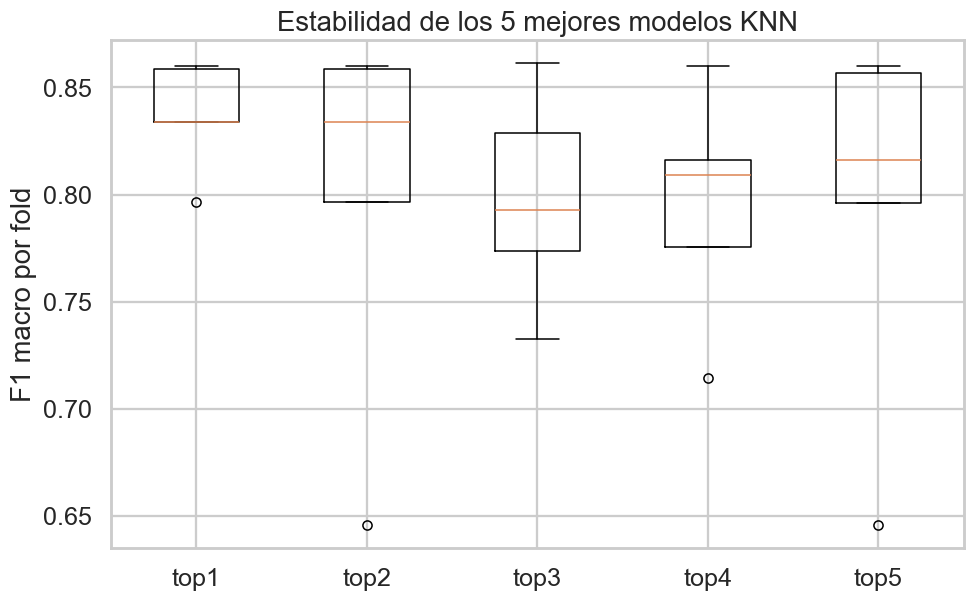

                                              params  mean_test_f1_macro
0  {'modelo__metric': 'euclidean', 'modelo__n_nei...            0.836567
1  {'modelo__metric': 'manhattan', 'modelo__n_nei...            0.798919
2  {'modelo__metric': 'euclidean', 'modelo__n_nei...            0.797790
3  {'modelo__metric': 'manhattan', 'modelo__n_nei...            0.795128
4  {'modelo__metric': 'manhattan', 'modelo__n_nei...            0.794973


In [16]:
# Pipeline KNN
pipeline_knn = Pipeline([
    ('preprocesado', preprocesado),
    ('seleccionador', SelectKBest(score_func = mutual_info_classif)),
    ('modelo', KNeighborsClassifier())
])

param_grid_knn = {
    'seleccionador__k' : [5,7,9,11,13],
    'modelo__n_neighbors' : [5,7,9,11,13],
    'modelo__weights' : ['uniform', 'distance'],
    'modelo__metric' : ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    estimator = pipeline_knn,
    param_grid = param_grid_knn,
    scoring = scoring,
    cv = 5,
    n_jobs = -1,
    verbose = 1,
    refit = 'f1_macro'
)

# Entrenamos
grid_knn.fit(X_train, y_train)

# Generamos y analizamos los resultados
results_knn = pd.DataFrame(grid_knn.cv_results_)
results_knn = results_knn.sort_values('mean_test_f1_macro', ascending=False).reset_index(drop=True)

m0 = results_knn[cols_folds].iloc[0]
m1 = results_knn[cols_folds].iloc[1]
m2 = results_knn[cols_folds].iloc[2]
m3 = results_knn[cols_folds].iloc[3]
m4 = results_knn[cols_folds].iloc[4]

plt.figure(figsize=(10, 6))
plt.boxplot([m0.values, m1.values, m2.values, m3.values, m4.values],
            tick_labels=['top1', 'top2', 'top3', 'top4', 'top5'])
plt.ylabel('F1 macro por fold')
plt.title('Estabilidad de los 5 mejores modelos KNN')
plt.show()
plt.close()

print(results_knn[['params', 'mean_test_f1_macro']].head(5))

Fitting 5 folds for each of 150 candidates, totalling 750 fits


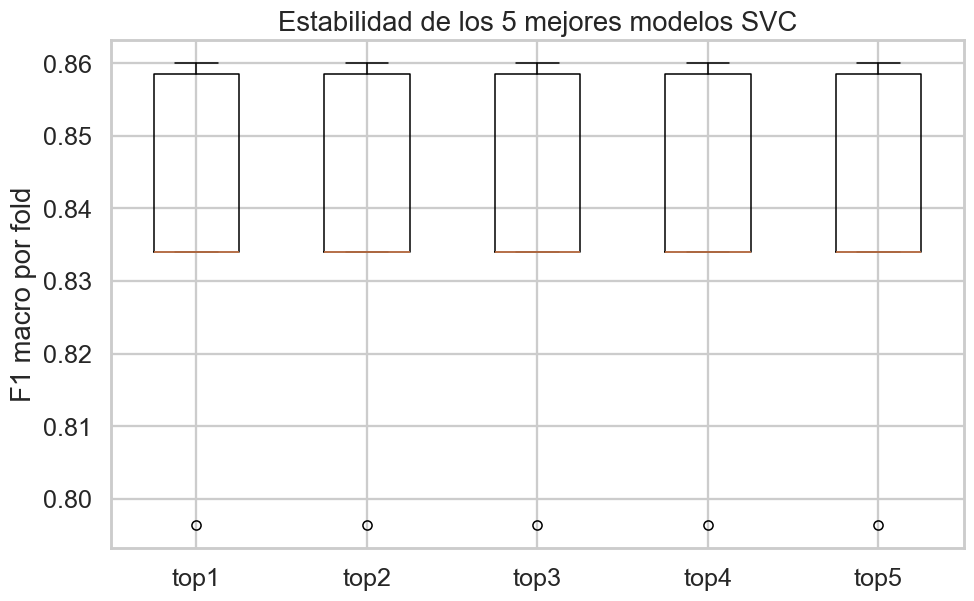

                                              params  mean_test_f1_macro
0  {'modelo__C': 100, 'modelo__gamma': 0.01, 'mod...            0.836567
1  {'modelo__C': 1, 'modelo__gamma': 0.01, 'model...            0.836567
2  {'modelo__C': 100, 'modelo__gamma': 0.1, 'mode...            0.836567
3  {'modelo__C': 100, 'modelo__gamma': 0.1, 'mode...            0.836567
4  {'modelo__C': 100, 'modelo__gamma': 0.1, 'mode...            0.836567


In [17]:
# Pipeline SVM
pipeline_svc = Pipeline([
    ('preprocesado', preprocesado),
    ('seleccionador', SelectKBest(score_func = mutual_info_classif)),
    ('modelo', SVC(probability = True,
                   random_state = seed,
                   class_weight='balanced'))
])

param_grid_svc = [
    {
        'seleccionador__k':  [5,7,9,11,13],
        'modelo__kernel':    ['linear'],
        'modelo__C':         [0.001, 0.1, 1, 10, 100]
    },
    {
        'seleccionador__k':  [5,7,9,11,13],
        'modelo__kernel':    ['rbf'],
        'modelo__C':         [0.001, 0.1, 1, 10, 100],
        'modelo__gamma':     [0.001, 0.01, 0.1, 1, 10]
    }
]

grid_svc = GridSearchCV(
    estimator = pipeline_svc,
    param_grid = param_grid_svc,
    scoring = scoring,
    refit = 'f1_macro',
    cv = 5,
    n_jobs = -1,
    verbose = 1, 
)

# Entrenamos
grid_svc.fit(X_train, y_train)

# Generamos y analizamos los resultados
results_svc = pd.DataFrame(grid_svc.cv_results_)
results_svc = results_svc.sort_values('mean_test_f1_macro', ascending=False).reset_index(drop=True)

m0 = results_svc[cols_folds].iloc[0]
m1 = results_svc[cols_folds].iloc[1]
m2 = results_svc[cols_folds].iloc[2]
m3 = results_svc[cols_folds].iloc[3]
m4 = results_svc[cols_folds].iloc[4]

plt.figure(figsize=(10, 6))
plt.boxplot([m0.values, m1.values, m2.values, m3.values, m4.values],
            tick_labels=['top1', 'top2', 'top3', 'top4', 'top5'])
plt.ylabel('F1 macro por fold')
plt.title('Estabilidad de los 5 mejores modelos SVC')
plt.show()
plt.close()

print(results_svc[['params', 'mean_test_f1_macro']].head(5))

Fitting 5 folds for each of 1080 candidates, totalling 5400 fits


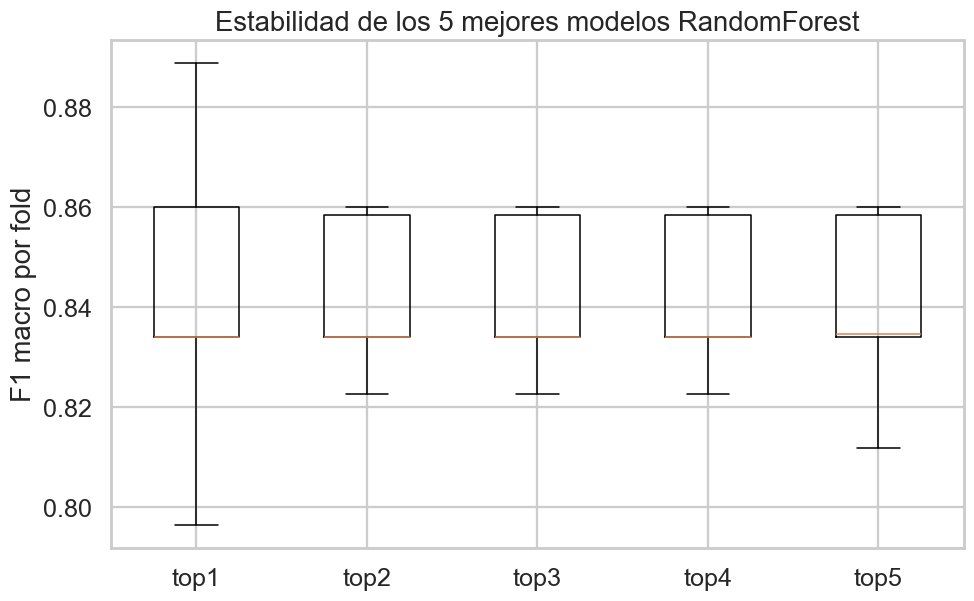

In [18]:
# Pipeline RandomForest
pipeline_rf = Pipeline([
    ('preprocesado', preprocesado),
    ('seleccionador', SelectKBest(score_func=mutual_info_classif)),
    ('modelo', RandomForestClassifier(
        random_state=seed,
        class_weight='balanced',
        n_jobs=-1
    ))
])

param_grid_rf = {
    'seleccionador__k': [5, 7, 9, 11, 13],
    'modelo__n_estimators': [100, 300, 500],
    'modelo__max_depth': [None, 5, 10, 20],
    'modelo__min_samples_split': [2, 5, 10],
    'modelo__min_samples_leaf': [1, 2, 4],
    'modelo__max_features': ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf,
    scoring=scoring,
    refit='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1,
)

grid_rf.fit(X_train, y_train)

# Generamos y analizamos los resultados
results_rf = pd.DataFrame(grid_rf.cv_results_)
results_rf = results_rf.sort_values('mean_test_f1_macro', ascending=False).reset_index(drop=True)

m0 = results_rf[cols_folds].iloc[0]
m1 = results_rf[cols_folds].iloc[1]
m2 = results_rf[cols_folds].iloc[2]
m3 = results_rf[cols_folds].iloc[3]
m4 = results_rf[cols_folds].iloc[4]

plt.figure(figsize=(10, 6))
plt.boxplot([m0.values, m1.values, m2.values, m3.values, m4.values],
            tick_labels=['top1', 'top2', 'top3', 'top4', 'top5'])
plt.ylabel('F1 macro por fold')
plt.title('Estabilidad de los 5 mejores modelos RandomForest')
plt.show()
plt.close()

Fitting 5 folds for each of 810 candidates, totalling 4050 fits


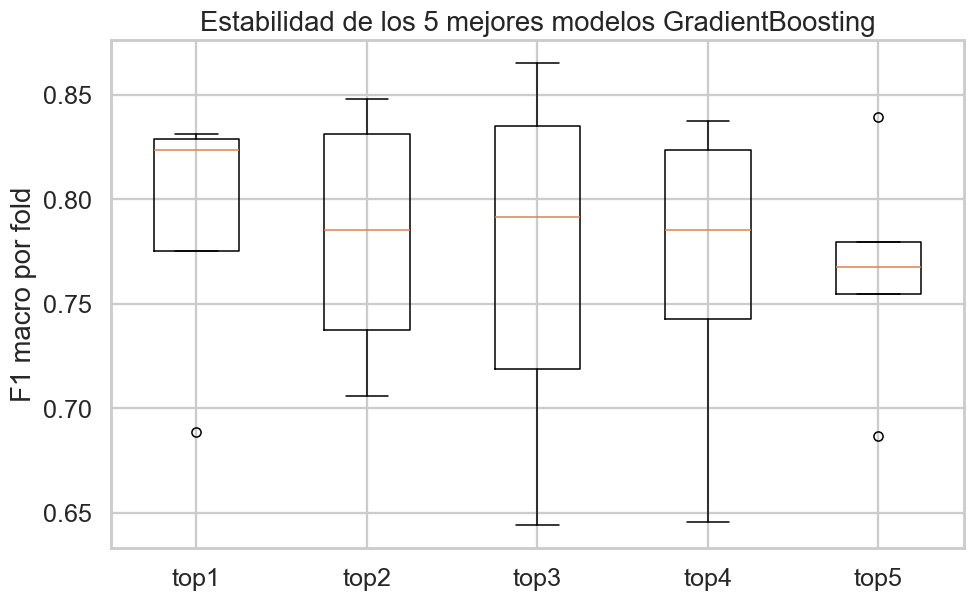

In [19]:
# Pipeline GradientBoosting
pipeline_gb = Pipeline([
    ('preprocesado', preprocesado),
    ('seleccionador', SelectKBest(score_func=mutual_info_classif)),
    ('modelo', GradientBoostingClassifier(random_state=seed))
])

param_grid_gb = {
    'seleccionador__k': [5,7,9,11,13],
    'modelo__n_estimators': [100, 200, 300],
    'modelo__learning_rate': [0.01, 0.05, 0.1],
    'modelo__max_depth': [3, 5, 7],
    'modelo__min_samples_split': [2, 5, 10],
    'modelo__subsample': [0.8, 1.0]
}

grid_gb = GridSearchCV(
    estimator=pipeline_gb,
    param_grid=param_grid_gb,
    scoring=scoring,
    refit='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1,
)
grid_gb.fit(X_train, y_train)

# Generamos y analizamos los resultados
results_gb = pd.DataFrame(grid_gb.cv_results_)
results_gb = results_gb.sort_values('mean_test_f1_macro', ascending=False).reset_index(drop=True)

m0 = results_gb[cols_folds].iloc[0]
m1 = results_gb[cols_folds].iloc[1]
m2 = results_gb[cols_folds].iloc[2]
m3 = results_gb[cols_folds].iloc[3]
m4 = results_gb[cols_folds].iloc[4]

plt.figure(figsize=(10, 6))
plt.boxplot([m0.values, m1.values, m2.values, m3.values, m4.values],
            tick_labels=['top1', 'top2', 'top3', 'top4', 'top5'])
plt.ylabel('F1 macro por fold')
plt.title('Estabilidad de los 5 mejores modelos GradientBoosting')
plt.show()
plt.close()

In [27]:
# Recopilación de los mejores score de cada grid
comparativa = pd.DataFrame([
    {'modelo': 'LogReg',
     'f1_macro_cv': grid_lr.best_score_,
     'params': grid_lr.best_params_},
    {'modelo': 'KNN',
     'f1_macro_cv': grid_knn.best_score_,
     'params': grid_knn.best_params_},
    {'modelo': 'SVM',
     'f1_macro_cv': grid_svc.best_score_,
     'params': grid_svc.best_params_},
    {'modelo': 'RandomForest',
     'f1_macro_cv': grid_rf.best_score_,
     'params': grid_rf.best_params_},
    {'modelo': 'GradientBoost',
     'f1_macro_cv': grid_gb.best_score_,
     'params': grid_gb.best_params_},
]).sort_values('f1_macro_cv', ascending=False)

print(comparativa)

print('-'*40)

# Diccionario con los best estimators
best_models = {
    'LogReg': grid_lr.best_estimator_,
    'KNN': grid_knn.best_estimator_,
    'SVM': grid_svc.best_estimator_,
    'RandomForest': grid_rf.best_estimator_,
    'GradientBoost': grid_gb.best_estimator_,
}

# Evaluamos todos en test
for nombre, modelo in best_models.items():
    y_pred = modelo.predict(X_test)
    print(f'\n---{nombre}---')
    print(f'Accuracy:     {accuracy_score(y_test, y_pred):.3f}')
    print(f'Balanced acc: {balanced_accuracy_score(y_test, y_pred):.3f}')
    print(f'F1 macro:     {f1_score(y_test, y_pred, average="macro"):.3f}')

          modelo  f1_macro_cv  \
3   RandomForest     0.842669   
0         LogReg     0.836567   
1            KNN     0.836567   
2            SVM     0.836567   
4  GradientBoost     0.789463   

                                              params  
3  {'modelo__max_depth': 20, 'modelo__max_feature...  
0  {'modelo__C': 0.01, 'modelo__penalty': 'l2', '...  
1  {'modelo__metric': 'euclidean', 'modelo__n_nei...  
2  {'modelo__C': 0.1, 'modelo__kernel': 'linear',...  
4  {'modelo__learning_rate': 0.1, 'modelo__max_de...  
----------------------------------------

---LogReg---
Accuracy:     0.942
Balanced acc: 0.951
F1 macro:     0.856

---KNN---
Accuracy:     0.947
Balanced acc: 0.667
F1 macro:     0.646

---SVM---
Accuracy:     0.942
Balanced acc: 0.951
F1 macro:     0.856

---RandomForest---
Accuracy:     0.942
Balanced acc: 0.951
F1 macro:     0.856

---GradientBoost---
Accuracy:     0.947
Balanced acc: 0.667
F1 macro:     0.646


### Resumen del análisis de estabilidad

Los cinco boxplots de las mejores combinaciones por modelo revelan patrones distintos que aportan información relevante para la comparación por scores medios:

**LogisticRegression y SVM presentan cajas idénticas en las cinco mejores combinaciones.** Esto indica que el grid ha encontrado un tope: múltiples valores de C (y de k) producen exactamente los mismos scores por fold. Lejos de ser un problema, esto es una señal de robustez en nuestro modelo. El modelo ha identificado una regla de decisión estable que no depende exclusivamente del tuning de hiperparámetros, coherente con la estructura analizada en el EDA.

**KNN muestra cajas distintas entre los cinco mejores.** Los scores por fold varían de aproximadamente 0,72 a 0,86 entre combinaciones, con bigotes largos y outliers por debajo de 0,65. Esto refleja que KNN es sensible tanto a la métrica como al número de vecinos, lo cual es esperable dado que se trata de un modelo basado en distancias que sufre especialmente en espacios con muchas variables dummy.

**RandomForest presenta un top1 con bigote largo hasta 0,89 y top2-top5 más estrechos.** La ligera ventaja de RandomForest en el CV medio se apoya parcialmente en un fold único de su mejor combinación, no en una superioridad sistemática sobre el resto de modelos (ya que no mantiene ese resultado en el resto de cajas). Las combinaciones top2 a top5 de RandomForest están al mismo nivel que los top5 de LogisticRegression y SVM.

**GradientBoosting es el modelo menos estable.** Muestra rangos amplios en todas las combinaciones del top5 (de 0,65 a 0,87), outliers visibles y medianas por debajo de las de los otros modelos. Es coherente con su último puesto en la comparativa final: no solo rinde peor, sino que rinde peor de forma inconsistente.

**Conclusión para la selección de modelo.** La estabilidad refuerza la decisión basada en parsimonia. Los tres modelos empatados en el score medio (LogisticRegression, SVM, RandomForest) no solo tienen rendimiento equivalente, sino que los dos lineales son además los más estables entre folds.

### Decisión final sobre el modelo

Aplicando el principio de parsimonia y primando la interpretabilidad del modelo siempre que no exista una diferencia de rendimiento sustancial, mi elección es en favor de **LogisticRegression** con `C=0.01` y `penalty='l2'`.

**Justificación:**

Los resultados en test muestran que tres modelos LogisticRegression, SVM y RandomForest obtienen métricas idénticas: accuracy 0.942, balanced_accuracy 0.951 y f1_macro 0.856. La ligera ventaja de RandomForest en CV (0.843 frente a 0.837) desaparece en test.

Ante rendimientos equivalentes entre una familia lineal y dos no lineales (kernel y ensamblado), el criterio de parsimonia nos ayuda a elegir el modelo más simple. Adicionalmente, LogisticRegression aporta ventajas que los de ensamblado no ofrecen:

1. Sus coeficientes son directamente interpretables como efectos sobre los odds del evento predicho, lo que permite explicaciones del tipo 'pertenecer al grupo X multiplica la probabilidad de ser Replaced por Y' (que las realizaremos a continuación).
2. Su espacio de hiperparámetros está saturado en el tope (múltiples combinaciones de C logran el mismo score), lo que indica que el modelo ha aprendido una regla estable e independiente de la regularización.
3. Su estabilidad por folds es máxima entre los cinco modelos analizados, con los cinco mejores candidatos compartiendo exactamente la misma distribución de scores por fold.

KNN y GradientBoosting quedan descartados pese a presentar accuracy superior en test (0.947). Ambos muestran una balanced_accuracy de 0.667 y f1_macro de 0.646, lo que indica que ignoran completamente la clase minoritaria.

**Rendimiento final del modelo seleccionado en test:**
- Accuracy: 0.942
- Balanced accuracy: 0.951
- F1 macro: 0.856

La balanced_accuracy de 0.951 confirma que el modelo identifica adecuadamente las tres clases del target, no únicamente las mayoritarias.

              precision    recall  f1-score   support

    Modified      1.000     0.854     0.921       240
    Replaced      0.478     1.000     0.646        32
   Unchanged      1.000     1.000     1.000       328

    accuracy                          0.942       600
   macro avg      0.826     0.951     0.856       600
weighted avg      0.972     0.942     0.950       600



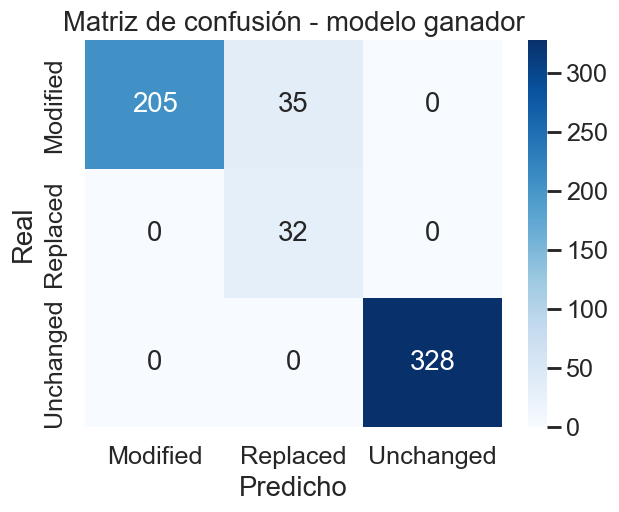

In [29]:
# Construcción modelo ganador (Logistic Regression)

pipeline_final = Pipeline([
    ('preprocesado', preprocesado),
    ('seleccionador', SelectKBest(score_func = mutual_info_classif,
                                 k = 13)),
    ('modelo', LogisticRegression(max_iter = 2000,
                                 random_state = seed,
                                 class_weight = 'balanced',
                                 C = 0.01))
])
pipeline_final.fit(X_train, y_train)
y_pred = pipeline_final.predict(X_test)

# Classification report 
print(classification_report(y_test, y_pred, digits=3))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=pipeline_final.classes_)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=pipeline_final.classes_, yticklabels=pipeline_final.classes_)
plt.xlabel('Predicho'); plt.ylabel('Real')
plt.title(f'Matriz de confusión - modelo ganador')
plt.tight_layout(); plt.show()

In [30]:
# Diferencia train/test del modelo ganador
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

y_pred_train = pipeline_final.predict(X_train)
y_pred_test = pipeline_final.predict(X_test)

gap_metrics = pd.DataFrame({
    'train': [
        accuracy_score(y_train, y_pred_train),
        balanced_accuracy_score(y_train, y_pred_train),
        f1_score(y_train, y_pred_train, average='macro'),
    ],
    'test': [
        accuracy_score(y_test, y_pred_test),
        balanced_accuracy_score(y_test, y_pred_test),
        f1_score(y_test, y_pred_test, average='macro'),
    ],
}, index=['accuracy', 'balanced_acc', 'f1_macro'])

gap_metrics['gap'] = gap_metrics['train'] - gap_metrics['test']
print(gap_metrics.round(3))

              train   test    gap
accuracy      0.930  0.942 -0.012
balanced_acc  0.942  0.951 -0.010
f1_macro      0.835  0.856 -0.021


### Evaluación final del modelo ganador

**Rendimiento por clase:**

| Clase | Precision | Recall | F1-score | Support |
|---|---|---|---|---|
| Modified | 1.000 | 0.854 | 0.921 | 240 |
| Replaced | 0.478 | 1.000 | 0.646 | 32 |
| Unchanged | 1.000 | 1.000 | 1.000 | 328 |

**Lectura de los resultados:**

La clase **Unchanged** se predice con exactitud perfecta (precision y recall de 1.000): todos los empleados con `Automation_Risk=Low` caen en este grupo.

La clase **Modified** presenta precision perfecta (1.000) y recall de 0.854. Esto significa que cuando el modelo predice Modified nunca se equivoca, pero deja 35 casos reales de Modified sin clasificar como tales los clasifica como Replaced.

La clase **Replaced** tiene recall perfecto (1.000) pero precision de 0.478. El modelo detecta **todos** los casos reales de reemplazo en el test (32 de 32), pero a cambio genera 35 falsos positivos: empleados marcados como Replaced que en realidad serán Modified. Este intercambio es deseable en un problema de detección de riesgo: prevenir el 100% de los reemplazos reales compensa la generación de alertas sobre casos que finalmente serán modificaciones menos drásticas.

La matriz de confusión confirma que los únicos errores se concentran en la frontera Modified/Replaced, ambas pertenecientes al subgrupo `Automation_Risk=High` que el EDA identificó como la zona ambigua del problema.

### Diagnóstico de sobreajuste

El gap train-test es negativo o nulo en las tres métricas:
- Accuracy: −0.012
- Balanced accuracy: −0.010
- F1 macro: −0.021

El test rinde ligeramente mejor que train en las tres métricas, lo que descarta cualquier forma de sobreajuste. El comportamiento es consistente con un modelo regularizado (`C=0.1`) y ponderado por clases (`class_weight='balanced'`) que prioriza generalización sobre memorización del conjunto de entrenamiento. La ligera ventaja del test cae dentro del rango esperable por variación muestral entre los 1400 casos de train y los 600 de test.

### F. INTERPRETACIÓN DE PARÁMETROS DEL MODELO GANADOR
En esta sección realizaremos lo siguiente:
- Obtención de los coeficientes
- Interpretación de los mismos

In [31]:
# Nombres de las variables despues del preprocesado
feat_preprocessed = pipeline_final.named_steps['preprocesado'].get_feature_names_out()

# Las variables seleccionadas por SelectKBest
mask = pipeline_final.named_steps['seleccionador'].get_support()
feat_seleccionadas = feat_preprocessed[mask]

print(f'Features que entran al modelo ({len(feat_seleccionadas)}):')
for f in feat_seleccionadas:
    print(f'  • {f}')

Features que entran al modelo (13):
  • categoricas__Job_Role_Digital Marketer
  • categoricas__Job_Role_Supervisor
  • categoricas__Job_Role_Teacher
  • categoricas__ai_risk_combined_High_Low
  • categoricas__ai_risk_combined_High_Medium
  • categoricas__ai_risk_combined_Low_High
  • categoricas__ai_risk_combined_Low_Low
  • categoricas__ai_risk_combined_Low_Medium
  • categoricas__ai_risk_combined_Medium_High
  • categoricas__ai_risk_combined_Medium_Low
  • categoricas__ai_risk_combined_Medium_Medium
  • ordinales__AI_Adoption_Level
  • ordinales__Automation_Risk


In [33]:
# Extracción coeficientes
clases = pipeline_final.classes_
coef_matrix = pipeline_final.named_steps['modelo'].coef_

coef_df = pd.DataFrame(
    coef_matrix.T,       
    index=feat_seleccionadas,
    columns=clases
)

print('Matriz de coeficientes:')
print(coef_df.round(3))

Matriz de coeficientes:
                                             Modified  Replaced  Unchanged
categoricas__Job_Role_Digital Marketer          0.013     0.014     -0.027
categoricas__Job_Role_Supervisor               -0.011    -0.005      0.016
categoricas__Job_Role_Teacher                  -0.017     0.025     -0.009
categoricas__ai_risk_combined_High_Low         -0.237    -0.106      0.343
categoricas__ai_risk_combined_High_Medium      -0.271    -0.287      0.558
categoricas__ai_risk_combined_Low_High         -0.283    -0.115      0.398
categoricas__ai_risk_combined_Low_Low          -0.175    -0.010      0.186
categoricas__ai_risk_combined_Low_Medium       -0.229    -0.036      0.265
categoricas__ai_risk_combined_Medium_High       0.594    -0.325     -0.269
categoricas__ai_risk_combined_Medium_Low        0.513    -0.054     -0.459
categoricas__ai_risk_combined_Medium_Medium     0.501    -0.141     -0.360
ordinales__AI_Adoption_Level                   -0.201     0.801     -0.599
o

In [34]:
odds_ratios_replaced = np.exp(coef_df['Replaced']).sort_values(ascending=False)
print('Odds ratios para Replaced (ordenados):')
print(odds_ratios_replaced.round(2))

Odds ratios para Replaced (ordenados):
ordinales__Automation_Risk                     2.31
ordinales__AI_Adoption_Level                   2.23
categoricas__Job_Role_Teacher                  1.03
categoricas__Job_Role_Digital Marketer         1.01
categoricas__Job_Role_Supervisor               0.99
categoricas__ai_risk_combined_Low_Low          0.99
categoricas__ai_risk_combined_Low_Medium       0.97
categoricas__ai_risk_combined_Medium_Low       0.95
categoricas__ai_risk_combined_High_Low         0.90
categoricas__ai_risk_combined_Low_High         0.89
categoricas__ai_risk_combined_Medium_Medium    0.87
categoricas__ai_risk_combined_High_Medium      0.75
categoricas__ai_risk_combined_Medium_High      0.72
Name: Replaced, dtype: float64


### Interpretación de los odds ratios

Los coeficientes del modelo se traducen a **odds ratios** (probabilidades relativas) para facilitar su lectura. Un odds ratio indica cuánto cambia la probabilidad de ser reemplazado cuando varía una característica del empleado o de su empresa:

- Un odds ratio **mayor(>) que 1** significa que esa característica **aumenta** el riesgo de reemplazo.
- Un odds ratio **menor(<) que 1** significa que esa característica **reduce** el riesgo.
- Un odds ratio **cercano a 1** significa que esa característica **no tiene efecto relevante**.

#### Los dos factores que mandan

| Variable | Odds ratio | Efecto |
|---|---|---|
| Automation_Risk | 2.31 | Multiplica el riesgo por 2.3 |
| AI_Adoption_Level | 2.23 | Multiplica el riesgo por 2.2 |

**Automation_Risk** es el riesgo de que el puesto sea automatizable por IA (por ejemplo: un cajero tiene más riesgo que un médico). Subir un nivel en esta variable (de Bajo a Medio, o de Medio a Alto) multiplica por 2.3 las probabilidades de que el empleado sea reemplazado.

**AI_Adoption_Level** mide cuánto adopta la IA la empresa donde trabaja el empleado. Subir un nivel aquí multiplica el riesgo por 2.2.

El efecto de estas dos variables **se acumula**. Un empleado con puesto de riesgo Alto en una empresa con adopción Alta acumula los dos multiplicadores varias veces sobre sí mismo. En el escenario extremo pasar del perfil más seguro (Bajo/Bajo) al más expuesto (Alto/Alto) las probabilidades de reemplazo se multiplican por aproximadamente **26 veces**.

Es decir, un empleado en el escenario más favorable tiene 26 veces menos probabilidades de ser reemplazado que uno en el escenario más crítico. Toda la diferencia se explica en base a dos variables que no dependen del empleado, sino del tipo de puesto y del tipo de empresa.

#### El rol del empleado:

| Variable | Odds ratio | Efecto |
|---|---|---|
| Job_Role_Teacher | 1.03 | +3% de riesgo |
| Job_Role_Digital Marketer | 1.01 | +1% de riesgo |
| Job_Role_Supervisor | 0.99 | −1% de riesgo |

Ser profesor, marketer digital o supervisor apenas modifica el riesgo de reemplazo por sí mismo. Los tres roles que sobrevivieron a la selección de variables presentan odds ratios prácticamente idénticos a 1, lo que significa que **no añaden información** al modelo más allá de lo que ya aportan las dos variables estructurales. Un profesor con Automation_Risk Alto tiene el mismo riesgo que un marketer digital con Automation_Risk Alto: no es el rol específico lo que importa, es el riesgo del puesto.

Por tanto cuando escuches alguna conversación del tipo 'los profesores están seguros' o 'los marketers serán reemplazados antes' no tienen soporte en estos datos. El riesgo viene del grado de automatización del puesto, no del nombre del rol.

#### Las combinaciones AI × Automation:

| Variable | Odds ratio | Efecto |
|---|---|---|
| ai_risk_combined_Medium_High | 0.72 | Reduce el riesgo un 28% |
| ai_risk_combined_High_Medium | 0.75 | Reduce el riesgo un 25% |
| ai_risk_combined_Medium_Medium | 0.87 | Reduce el riesgo un 13% |
| ai_risk_combined_Low_High | 0.89 | Reduce el riesgo un 11% |
| ai_risk_combined_High_Low | 0.90 | Reduce el riesgo un 10% |

Estas son combinaciones de las dos variables principales (por ejemplo, 'Automation Alto con Adopción Media'). Fueron creadas durante la fase de feature engineering con la idea de capturar posibles efectos de interacción, es decir, si la combinación de ambas factores podía tener un efecto distinto al de la suma de cada una por separado.

El resultado es que **no lo tienen**. Todos estos odds ratios están por debajo de 1 con efectos modestos (entre −10% y −30%), y van en dirección contraria a la que tendría sentido si fueran informativos.

#### Resumen narrativo

Mirando los odds de todas las variables juntas, la conclusión es contundente:

- **Dos factores explican el 95% del riesgo**: lo automatizable que es tu puesto y lo mucho que tu empresa invierte en IA.
- **Nada relacionado con tu persona aportan información predictiva adicional.**
- **No hay combinaciones mágicas** que te pongan en riesgo especial. Los efectos de las dos variables clave se suman de manera simple.

Para alguien que se pueda preguntar si su trabajo está en riesgo, las dos preguntas que realmente debe realizarse son:

1. ¿Mi puesto es de los que una IA puede automatizar?
2. ¿Mi empresa está invirtiendo activamente en IA?

Si ambas respuestas son 'sí', el riesgo se multiplica por 26 respecto al escenario opuesto. Si solo una lo es, el riesgo se multiplica por 2. Si ambas son 'no', el riesgo es marginal.

### G. VISUALIZACIÓN DE INSIGHTS CLAVES
En este bloque mostrare los siguientes insights acorde al estudio:
- El valor determinista de la variable Automation Risk
- Las variables realmente importantes que te ayuden a comprender tu futuro
- Comparación de escenarios de riesgo

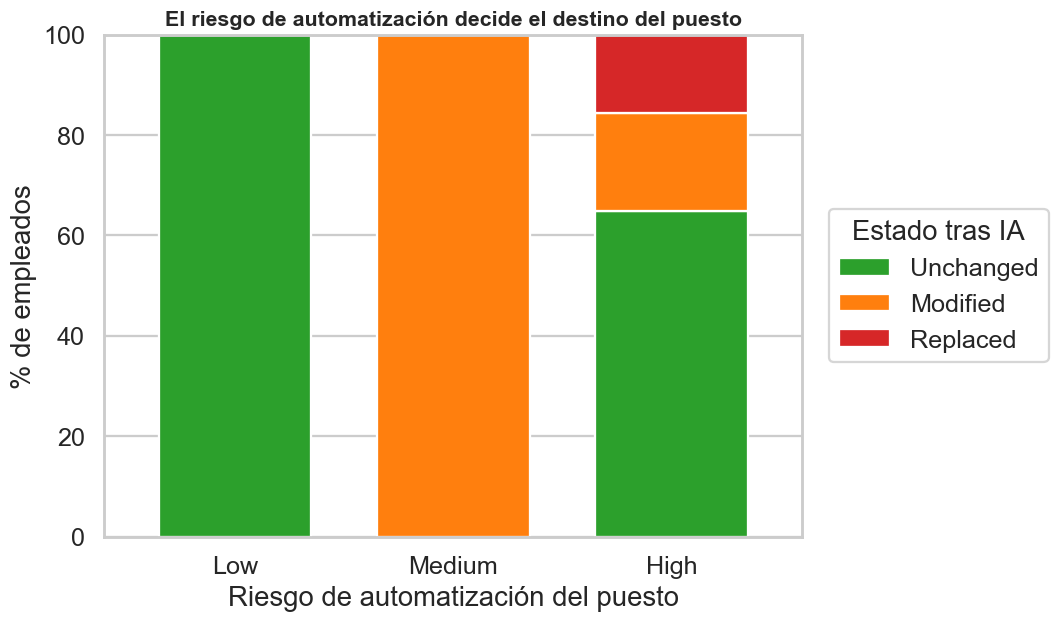

In [37]:
# Visualización del valor determinista de la variable Automation Risk
ct = pd.crosstab(df['Automation_Risk'], df['Job_Status'],
                 normalize='index') * 100
ct = ct[['Unchanged', 'Modified', 'Replaced']]

fig, ax = plt.subplots(figsize=(10, 6))

ct.plot(kind='bar', 
        stacked=True,
        ax=ax,
        color=[palette_status[c] for c in ct.columns], width=0.7)

ax.set_title('El riesgo de automatización decide el destino del puesto',
             fontsize=14,
             fontweight='bold')
ax.set_ylabel('% de empleados')
ax.set_xlabel('Riesgo de automatización del puesto')
ax.tick_params(axis='x', 
               rotation=0)
ax.legend(title='Estado tras IA',
          loc='center left', 
          bbox_to_anchor=(1.02, 0.5))
plt.tight_layout(); plt.show()

**Interpretación:** Los empleados con puestos de bajo riesgo de automatización mantuvieron su rol al 100%. En los de riesgo medio, prácticamente todos vieron su puesto modificado ya sea positivo/negativo. Los reemplazos por IA se concentran en una sola categoría: los puestos de alto riesgo de automatización, ademas de contener una proporcion equitativa a Modified.

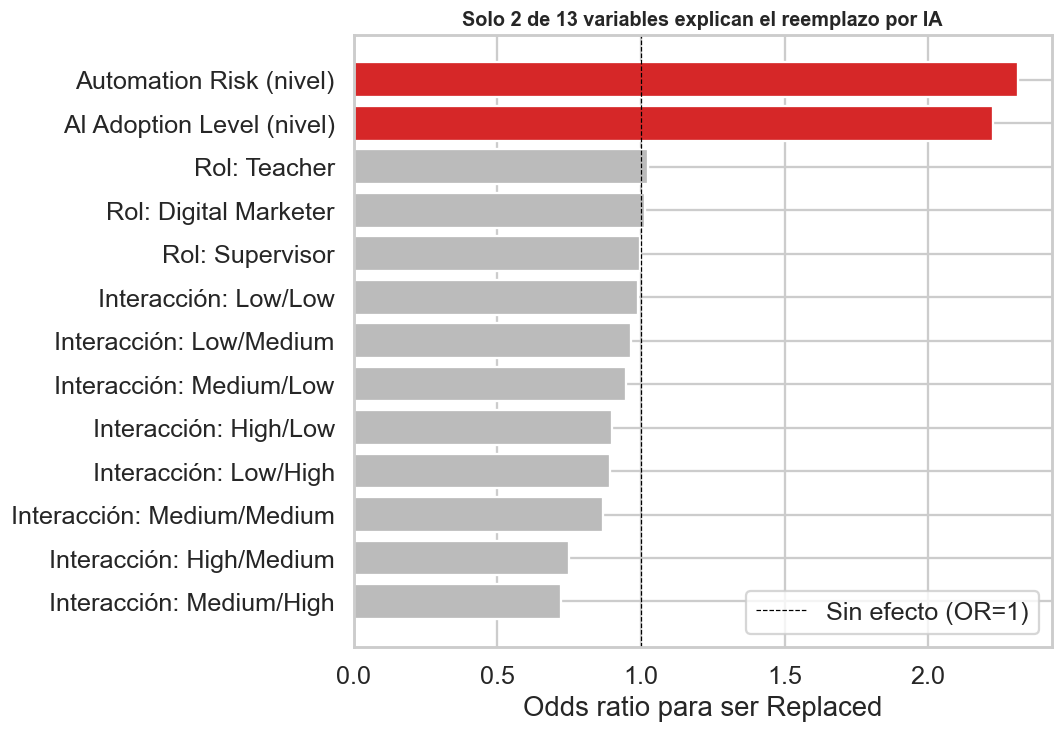

In [38]:
# Visualización de las variables realmente importantes que te ayuden a comprender tu futuro
or_replaced = np.exp(coef_df['Replaced']).sort_values()

# Renombramos etiquetas para que sean legibles
labels_map = {
    'ordinales__Automation_Risk': 'Automation Risk (nivel)',
    'ordinales__AI_Adoption_Level': 'AI Adoption Level (nivel)',
    'categoricas__Job_Role_Teacher': 'Rol: Teacher',
    'categoricas__Job_Role_Digital Marketer': 'Rol: Digital Marketer',
    'categoricas__Job_Role_Supervisor': 'Rol: Supervisor',
    'categoricas__ai_risk_combined_Low_Low': 'Interacción: Low/Low',
    'categoricas__ai_risk_combined_Low_Medium': 'Interacción: Low/Medium',
    'categoricas__ai_risk_combined_Medium_Low': 'Interacción: Medium/Low',
    'categoricas__ai_risk_combined_High_Low': 'Interacción: High/Low',
    'categoricas__ai_risk_combined_Low_High': 'Interacción: Low/High',
    'categoricas__ai_risk_combined_Medium_Medium': 'Interacción: Medium/Medium',
    'categoricas__ai_risk_combined_High_Medium': 'Interacción: High/Medium',
    'categoricas__ai_risk_combined_Medium_High': 'Interacción: Medium/High',
}
or_replaced.index = or_replaced.index.map(lambda x: labels_map.get(x, x))

# Rojo para los 2 drivers, gris para el resto
colors = ['#d62728' if v > 1.5 else '#bbbbbb' for v in or_replaced.values]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(or_replaced.index, 
        or_replaced.values,
        color=colors)
ax.axvline(1, color='black',
           linewidth=0.8,
           linestyle='--',
           label='Sin efecto (OR=1)')
ax.set_xlabel('Odds ratio para ser Replaced')
ax.set_title('Solo 2 de 13 variables explican el reemplazo por IA',
             fontsize=13,
             fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

**Interpretación:** Analicé 13 variables (rol específico, combinaciones, nivel educativo, experiencia, salario). Sin embargo, solo dos destacan: el riesgo del puesto y la adopción de IA de la empresa. Todas las demás tienen efecto ínfimo en el destino futuro del empleado.

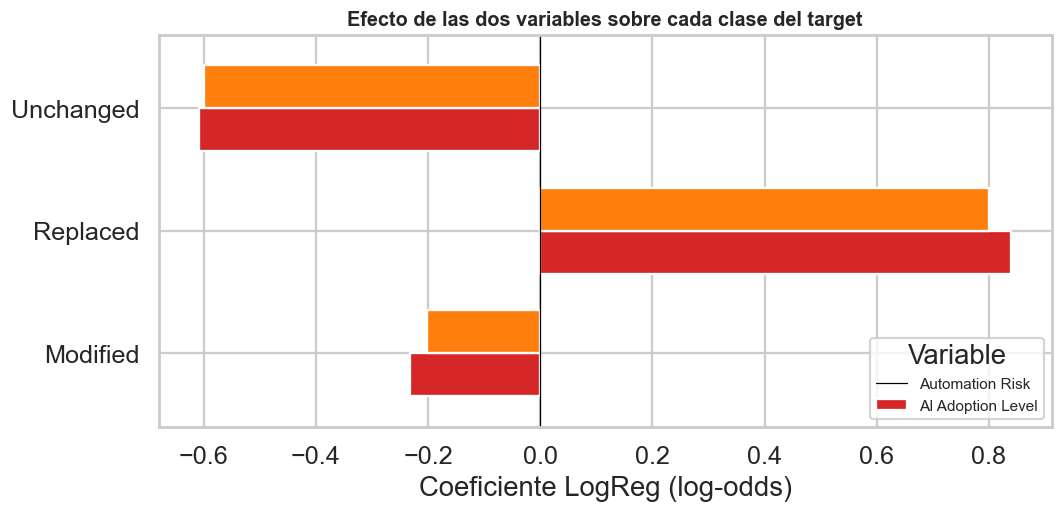

In [40]:
# Comportamiento de las 2 variables mas importantes en los 3 estados
fig, ax = plt.subplots(figsize=(10, 5))
top_drivers.plot(kind='barh', 
                 ax=ax, 
                 color=['#d62728', '#ff7f0e'],
                 width=0.7)

ax.axvline(0, 
           color='black',
           linewidth=0.8)
ax.set_xlabel('Coeficiente LogReg (log-odds)')
ax.set_title('Efecto de las dos variables sobre cada clase del target',
             fontsize=13, 
             fontweight='bold')

# Renombramos las variables en la leyenda para que sean legibles
ax.legend(['Automation Risk', 'AI Adoption Level'],
          title='Variable',
          fontsize=10, 
          loc='lower right')
ax.set_ylabel('')
plt.tight_layout(); plt.show()

**Interpretación:** Las dos variables actúan como un espejo mismo peso, misma dirección, mismo orden en las tres clases. El modelo no encontró una variable que domine sobre otra: Automation_Risk y AI_Adoption_Level son intercambiables en magnitud. Cualquiera de las dos, por sí sola, explica aproximadamente la mitad del riesgo de reemplazo.

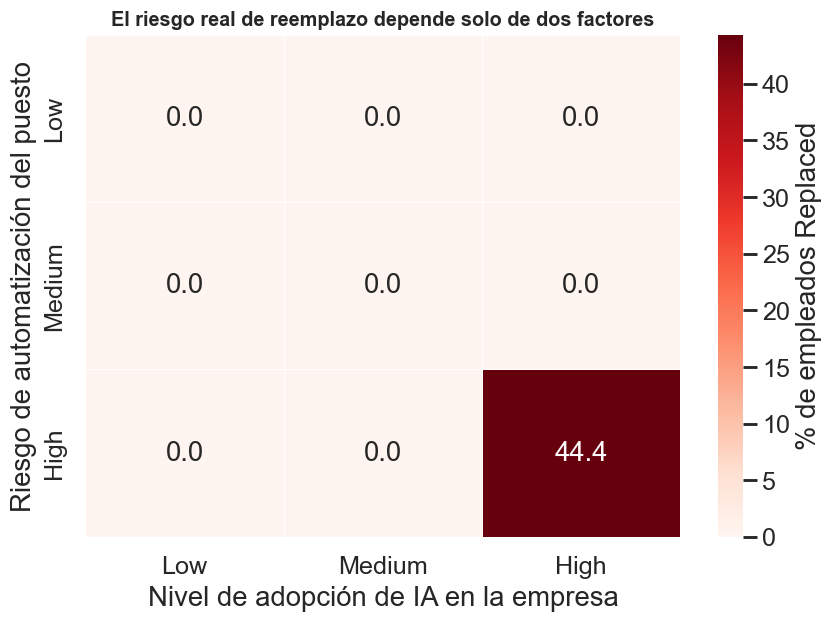

In [39]:
# Comparación de escenarios de riesgo
pivot = (df.assign(is_replaced=(df['Job_Status']=='Replaced').astype(int))
           .groupby(['Automation_Risk', 'AI_Adoption_Level'], 
                    observed=True)['is_replaced']
           .mean() * 100).unstack()

# Ordenamos los ejes para que la escalada sea visualmente clara
pivot = pivot.reindex(['Low', 'Medium', 'High'])
pivot = pivot[['Low', 'Medium', 'High']]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot, 
            annot=True, 
            fmt='.1f',
            cmap='Reds',
            cbar_kws={'label': '% de empleados Replaced'},
            linewidths=0.5,
            ax=ax)
ax.set_title('El riesgo real de reemplazo depende solo de dos factores',
             fontsize=13, 
             fontweight='bold')
ax.set_xlabel('Nivel de adopción de IA en la empresa')
ax.set_ylabel('Riesgo de automatización del puesto')
plt.tight_layout(); plt.show()

**Interpretación:** El mapa de calor nos indica la realidad. Los reemplazos se concentran en una sola celda (puestos de alto riesgo en empresas de alta adopción). El resto del grid está prácticamente vacío. Esto es una muestra que reivindica todo lo que venimos explicando.

### H. CONCLUSIONES DEL PROYECTO

El análisis completo de la base de datos nos permite extraer tres conclusiones que responden a la pregunta surgida para el desarrollo del proyecto: ¿qué determina el destino de un empleado ante la adopción de IA en su empresa?

**Primero, lo que no importa.** Ninguna característica individual del empleado (edad, años de experiencia, salario previo, satisfacción laboral, productividad, género, nivel educativo, horas trabajadas o trabajo remoto) tiene capacidad predictiva relevante sobre si su puesto será reemplazado, modificado o mantenido. Este hallazgo, confirmado tanto desde el EDA como desde los coeficientes del modelo final, contradice el pensamiento habitual según la cual: la preparación personal, el desempeño o la experiencia nos protegerían frente a la automatización. En estos datos, no lo hacen.

**Segundo, lo que SÍ importa.** Dos variables explican prácticamente toda la capacidad predictiva del modelo: el riesgo de automatización inherente al puesto desempeñado (`Automation_Risk`) y la intensidad con que la empresa adopta tecnologías de IA (`AI_Adoption_Level`). Ambas con peso equivalente, ambas con efectos que se suman de manera independiente, sin que sus combinaciones cruzadas añadan información adicional. Un puesto automatizable en una empresa que adopta IA de forma agresiva es la combinación crítica; un puesto no automatizable en una empresa poco adoptante es el escenario más seguro para un empleado.

**Tercero, la cuantificación del efecto.** Pasar del escenario más favorable al más crítico multiplica las probabilidades de reemplazo por aproximadamente 26 veces. Esta cifra recoge de forma cuantitativa la diferencia entre estar en una posición expuesta y una protegida.

**Implicación.** Para un profesional que quiera valorar su propio riesgo ante la IA, las dos preguntas que debe hacerse según estos datos no son sobre su perfil personal (formación, edad, rendimiento), sino sobre su entorno:

1. ¿Las tareas de mi puesto son automatizables por IA?
2. ¿Mi empresa está invirtiendo activamente en adoptar IA?

Según estas respuestas, el riesgo real queda identificado sin necesidad de mirar ninguna otra variable. El modelo final alcanza 95,1% de balanced accuracy precisamente porque el problema, una vez aisladas las dos variables estructurales, es casi determinista.

**Reflexión final.** Este proyecto nos da un vuelco a la narrativa habitual sobre la IA en el trabajo. La conversación pública (la cual surgió la idea del desarrollo de este proyecto) suele centrarse en cómo los ciudadanos debemos prepararnos, reciclarnos y adaptarnos para sobrevivir a la automatización. Los datos de este estudio, nos muestran algo más incómodo: el destino se decide antes de que nosotros y nuestras decisiones puedan intervenir. Esto no invalida la preparación individual como estrategia de adopción, pero sí desplaza el foco de la conversación: la decisión crítica no es tanto cómo uno se forma, sino dónde uno trabaja y en qué tipo de puesto.

### I. LIMITACIONES DEL PROYECTO

Un científico de datos debe reconocer los límites de sus propias conclusiones en un proyecto. Este proyecto presenta tres limitaciones principales que se debe tener en cuenta al interpretar los resultados obtenidos:

**Primera: La naturaleza sintética de la base de datos.** Durante el EDA se identificaron varias señales que indicaban que los datos fueron generados de forma sintética: distribuciones similares a la uniforme (variables numéricas), ausencia total de outliers según el criterio IQR, rangos acotados y proporciones entre categorías artificialmente equilibradas. Esto no invalida el proceso riguroso que he llevado a cabo, pero sí implica que las conclusiones cuantitativas no deben extrapolarse a poblaciones reales sin validación extra. El factor multiplicador de 26× entre escenarios, por ejemplo, es válido dentro de los datos que disponemos, pero no necesariamente en otros datos.

**Segunda: Tamaño reducido de la clase minoritaria.** La clase `Replaced` representa solo el 5,3% de la base de datos, lo que equivale a 106 casos en total y aproximadamente 32 casos en el conjunto de test. Cualquier métrica calculada específicamente sobre esta clase tiene IC amplios y debería leerse como meramente informativa, no como afirmación estadística. La identificación de Replaced por parte del modelo (recall de 1,0) es un resultado muy bueno pero a su vez frágil: Es decir con pequeñas variaciones de la muestra ese recall caería posiblemente varios puntos.

**Tercera: Ausencia de variable temporal.** La base de datos no contiene información sobre el momento de la adopción de la IA, la antigüedad del empleado en el puesto al ocurrir el cambio, ni la ventana temporal en la que se produjo el reemplazo o modificación. Esto impide analizar el proceso de reemplazo como algo dinámico y por lo tanto limita las conclusiones a una fotografía estática final. Un análisis riguroso requeriría variables temporales y preferentemente un grupo de control de empresas sin adopción de IA para estimar el efecto neto de la intervención (pero en este caso no contamos con ello).

**Implicación.** El proyecto debe leerse como una puesta en práctica de lo que es un flujo completo y metodológicamente correcto, cuyo valor principal reside en el flujo de decisiones desarrolladas, la selección del modelo (por el principio de parsimonia, aunque existen varios como la regla 1-se), la interpretación de coeficientes. Para aplicar conclusiones a contextos profesionales reales, sería necesario replicar el análisis sobre una base de datos que contuviese información temporal y una muestra de observaciones suficientemente grande de la clase `Replaced`. Sin embargo, y no menos importante esto no resta valor al proceso llevado a cabo.